# Closed-box surface-current leakage tally

This notebook estimates the total neutron and photon leakage from the full
Am-Be paraffin/cabinet geometry by placing a closed surface-current tally box
around the setup.

Unlike the point-detector flux tallies used in the later notebooks, this
calculation gives a global leakage estimate through the six sides of the box.

# 1) Setup and imports

This notebook estimates the global neutron and photon leakage from the full
Am-Be paraffin/cabinet geometry.

A closed surface-current tally box is placed around the shared OpenMC geometry.
The box is approximately $6 \times 6\ \mathrm{m}$ in the horizontal plane, with
the cabinet placed near one corner. The nearest box walls are placed about
$15\ \mathrm{cm}$ outside the cabinet outer surfaces.

Unlike the pointwise flux tallies used in the later notebooks, the surface
current tally estimates how many particles cross the closed box boundary.

The result is therefore a global leakage quantity, not a local detector dose
rate.

In [1]:
# ============================================================
# 1) Setup and imports
# ============================================================

from pathlib import Path
import shutil
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import openmc


# ------------------------------------------------------------
# Shared geometry/model module
# ------------------------------------------------------------

try:
    import ambe_base_model
    importlib.reload(ambe_base_model)

except ImportError as error:
    raise ImportError(
        "Could not import 'ambe_base_model.py'. "
        "Make sure it is located in the same folder as this notebook."
    ) from error


# ------------------------------------------------------------
# Base directories
# ------------------------------------------------------------

BASE_DIR = Path.cwd().resolve()

OUTPUT_DIR = BASE_DIR / "surface_current_leakage_outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"

RUN_DIR = BASE_DIR / "openmc_run_surface_current_leakage"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Plot/display settings
# ------------------------------------------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 120)


# ------------------------------------------------------------
# Source normalization
# ------------------------------------------------------------

SOURCE_NEUTRON_EMISSION = getattr(
    ambe_base_model,
    "SOURCE_NEUTRON_EMISSION",
    1.2e7,
)


print("Notebook 1.5 setup completed.")
print(f"Working directory: {BASE_DIR}")
print(f"Output directory:  {OUTPUT_DIR}")
print(f"Run directory:     {RUN_DIR}")
print(f"Source strength:   {SOURCE_NEUTRON_EMISSION:.3e} n/s")

Notebook 1.5 setup completed.
Working directory: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn
Output directory:  /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/surface_current_leakage_outputs
Run directory:     /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/openmc_run_surface_current_leakage
Source strength:   1.200e+07 n/s


# 2) Define simulation scenarios

Two OpenMC geometry scenarios are compared:

1. **Full geometry**  
   The complete Am-Be/paraffin/cabinet setup, including cabinet walls and lead shielding bricks.

2. **No cabinet / no lead**  
   The same Am-Be source, paraffin moderator, plastic parts, sample tubes and steel rods, but with the cabinet walls and lead shielding bricks removed.

The same closed leakage box is used for both scenarios. This ensures that the calculated leakage currents are compared through the same outer surfaces.

In [92]:
# ============================================================
# 2) Define simulation scenarios
# ============================================================

SCENARIOS = {
    "full_geometry": {
        "label": "Full geometry",
        "include_cabinet": True,
        "include_lead": True,
        "description": (
            "Complete geometry including cabinet walls and lead shielding bricks."
        ),
    },

    "no_cabinet_no_lead": {
        "label": "No cabinet / no lead",
        "include_cabinet": False,
        "include_lead": False,
        "description": (
            "Same source and moderator geometry, but without cabinet walls "
            "and without lead shielding bricks."
        ),
    },
}


scenario_summary_df = pd.DataFrame([
    {
        "scenario": scenario_name,
        "label": scenario_cfg["label"],
        "include_cabinet": scenario_cfg["include_cabinet"],
        "include_lead": scenario_cfg["include_lead"],
        "description": scenario_cfg["description"],
    }
    for scenario_name, scenario_cfg in SCENARIOS.items()
])

display(scenario_summary_df)

,scenario,label,include_cabinet,include_lead,description
0,full_geometry,Full geometry,True,True,Complete geometry including cabinet walls and lead shielding bricks.
1,no_cabinet_no_lead,No cabinet / no lead,False,False,"Same source and moderator geometry, but without cabinet walls and without lead shielding bricks."


# 3) Load geometry for both scenarios

The shared model builder in `ambe_base_model.py` is used to create both geometry scenarios.

The `full_geometry` case includes all objects, while the `no_cabinet_no_lead` case removes only the cabinet-wall and lead-brick parts. The internal source/moderator geometry is otherwise kept unchanged.

In [93]:
# ============================================================
# 3) Load geometry for both scenarios
# ============================================================

scenario_bases = {}

for scenario_name, scenario_cfg in SCENARIOS.items():
    print("=" * 70)
    print(f"Building geometry scenario: {scenario_name}")
    print("=" * 70)

    base = ambe_base_model.build_base_geometry_and_materials(
        verbose=False,
        include_cabinet=scenario_cfg["include_cabinet"],
        include_lead=scenario_cfg["include_lead"],
    )

    scenario_bases[scenario_name] = base

print()
print("Built geometry scenarios:")
for scenario_name, base in scenario_bases.items():
    print(
        f"  {scenario_name:20s}: "
        f"{len(base['materials'])} materials, "
        f"{len(base['geometry'].root_universe.cells)} root cells"
    )


# Use the full geometry as reference for cabinet dimensions and box placement.
reference_base = scenario_bases["full_geometry"]

CABINET_XMIN = reference_base["CABINET_XMIN"]
CABINET_XMAX = reference_base["CABINET_XMAX"]
CABINET_YMIN = reference_base["CABINET_YMIN"]
CABINET_YMAX = reference_base["CABINET_YMAX"]
CABINET_ZMIN = reference_base["CABINET_ZMIN"]
CABINET_ZMAX = reference_base["CABINET_ZMAX"]

print()
print("Reference cabinet bounds from full geometry:")
print(f"  x: {CABINET_XMIN:.1f} to {CABINET_XMAX:.1f} cm")
print(f"  y: {CABINET_YMIN:.1f} to {CABINET_YMAX:.1f} cm")
print(f"  z: {CABINET_ZMIN:.1f} to {CABINET_ZMAX:.1f} cm")

Building geometry scenario: full_geometry
Building geometry scenario: no_cabinet_no_lead

Built geometry scenarios:
  full_geometry       : 7 materials, 26 root cells
  no_cabinet_no_lead  : 7 materials, 12 root cells

Reference cabinet bounds from full geometry:
  x: -42.5 to 42.5 cm
  y: -33.5 to 33.5 cm
  z: -41.0 to 55.0 cm


# 4) Define common closed leakage box

A common closed rectangular box is used for both scenarios.

The box is placed so that the cabinet outer boundary of the full geometry is approximately $15\ \mathrm{cm}$ from the nearest box walls in the $-x$, $-y$ and $-z$ directions. The box then extends approximately $6\ \mathrm{m}$ in the positive $x$ and $y$ directions.

This places the full experimental setup near one corner of the leakage box, similarly to the intended experimental-room geometry.

In [94]:
# ============================================================
# 4) Define common closed leakage box
# ============================================================

BOX_CLEARANCE_CM = 15.0

BOX_SIZE_X_CM = 600.0
BOX_SIZE_Y_CM = 600.0
BOX_SIZE_Z_CM = 250.0


# ------------------------------------------------------------
# Physical placement of the closed leakage box
#
# The cabinet/setup is placed close to one corner of the box:
#
#   x-direction:
#       cabinet is 15 cm from the x_min wall
#
#   y-direction:
#       cabinet is 15 cm from the y_max wall
#
#   z-direction:
#       cabinet is 15 cm above the z_min wall/floor
#
# This is the physical placement used in the OpenMC surface-current tally.
# ------------------------------------------------------------

BOX_XMIN = CABINET_XMIN - BOX_CLEARANCE_CM
BOX_XMAX = BOX_XMIN + BOX_SIZE_X_CM

BOX_YMAX = CABINET_YMAX + BOX_CLEARANCE_CM
BOX_YMIN = BOX_YMAX - BOX_SIZE_Y_CM

BOX_ZMIN = CABINET_ZMIN - BOX_CLEARANCE_CM
BOX_ZMAX = BOX_ZMIN + BOX_SIZE_Z_CM


leakage_box = {
    "x_min": BOX_XMIN,
    "x_max": BOX_XMAX,
    "y_min": BOX_YMIN,
    "y_max": BOX_YMAX,
    "z_min": BOX_ZMIN,
    "z_max": BOX_ZMAX,
}


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

box_contains_cabinet = (
    BOX_XMIN < CABINET_XMIN
    and BOX_XMAX > CABINET_XMAX
    and BOX_YMIN < CABINET_YMIN
    and BOX_YMAX > CABINET_YMAX
    and BOX_ZMIN < CABINET_ZMIN
    and BOX_ZMAX > CABINET_ZMAX
)

if not box_contains_cabinet:
    raise RuntimeError(
        "The leakage box does not fully contain the reference cabinet geometry."
    )


clearance_summary_df = pd.DataFrame({
    "clearance": [
        "x_min wall to cabinet xmin",
        "x_max wall to cabinet xmax",
        "y_min wall to cabinet ymin",
        "y_max wall to cabinet ymax",
        "floor z_min to cabinet zmin",
        "ceiling z_max to cabinet zmax",
    ],
    "distance_cm": [
        CABINET_XMIN - BOX_XMIN,
        BOX_XMAX - CABINET_XMAX,
        CABINET_YMIN - BOX_YMIN,
        BOX_YMAX - CABINET_YMAX,
        CABINET_ZMIN - BOX_ZMIN,
        BOX_ZMAX - CABINET_ZMAX,
    ],
})

leakage_box_summary_df = pd.DataFrame({
    "quantity": [
        "BOX_XMIN",
        "BOX_XMAX",
        "BOX_YMIN",
        "BOX_YMAX",
        "BOX_ZMIN",
        "BOX_ZMAX",
        "BOX_SIZE_X_CM",
        "BOX_SIZE_Y_CM",
        "BOX_SIZE_Z_CM",
    ],
    "value_cm": [
        BOX_XMIN,
        BOX_XMAX,
        BOX_YMIN,
        BOX_YMAX,
        BOX_ZMIN,
        BOX_ZMAX,
        BOX_SIZE_X_CM,
        BOX_SIZE_Y_CM,
        BOX_SIZE_Z_CM,
    ],
})

display(leakage_box_summary_df)
display(clearance_summary_df)

print("Common closed leakage box defined.")
print(f"Box contains reference cabinet: {box_contains_cabinet}")

,quantity,value_cm
0,BOX_XMIN,-57.5
1,BOX_XMAX,542.5
2,BOX_YMIN,-551.5
3,BOX_YMAX,48.5
4,BOX_ZMIN,-56.0
5,BOX_ZMAX,194.0
6,BOX_SIZE_X_CM,600.0
7,BOX_SIZE_Y_CM,600.0
8,BOX_SIZE_Z_CM,250.0


,clearance,distance_cm
0,x_min wall to cabinet xmin,15.0
1,x_max wall to cabinet xmax,500.0
2,y_min wall to cabinet ymin,518.0
3,y_max wall to cabinet ymax,15.0
4,floor z_min to cabinet zmin,15.0
5,ceiling z_max to cabinet zmax,139.0


Common closed leakage box defined.
Box contains reference cabinet: True


# 5) Simple geometry visualization

A simple top-view and side-view visualization is used to check the placement of the common leakage box relative to the two geometry scenarios.

The plots are not OpenMC render plots. They are simplified geometric checks showing:

- the leakage box,
- the original cabinet outer boundary,
- the source center,
- the paraffin moderator,
- approximate lead-brick positions when present.

This is meant as a quick sanity check before running the surface-current simulations.

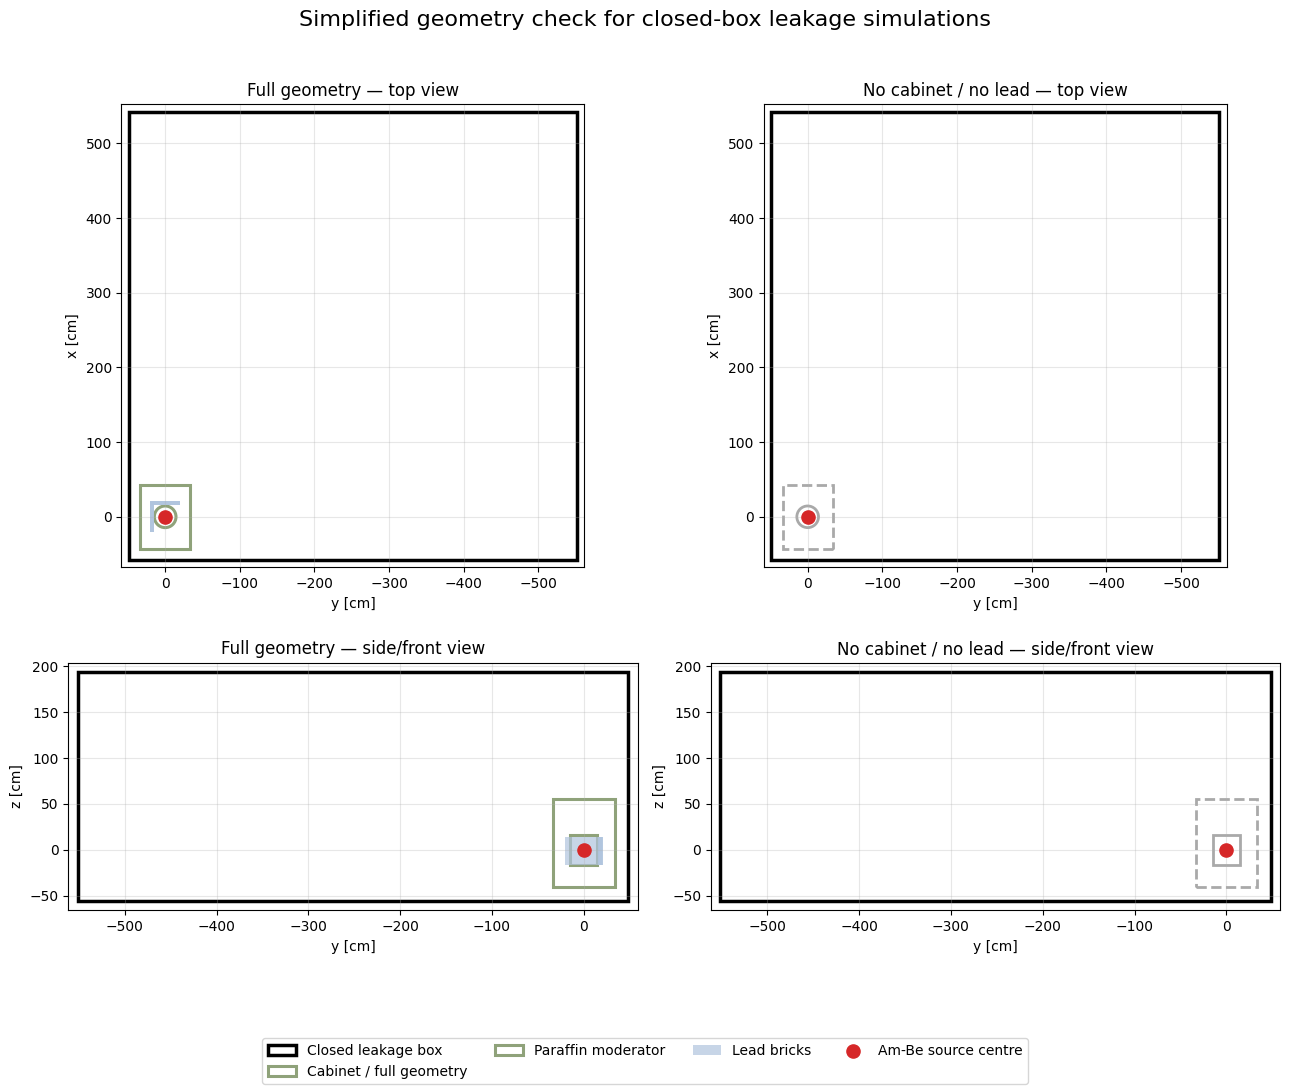

In [95]:
# ============================================================
# 5) Correct 2D geometry visualization:
#    top view = (y, x)
#    side/front view = (y, z)
# ============================================================

from matplotlib.patches import Rectangle, Circle
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Visual-orientation switches
# ------------------------------------------------------------

TOP_VIEW_MIRROR_Y = True
SIDE_VIEW_MIRROR_Y = False


# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------

MODEL_GREEN = "#8FA27A"       # green geometry colour
REFERENCE_GREY = "darkgrey"
LEAD_BLUE = "lightsteelblue"
SOURCE_RED = "tab:red"

FULL_CABINET_STYLE = dict(
    fill=False,
    edgecolor=MODEL_GREEN,
    linestyle="-",
    linewidth=2.2,
)

FULL_PARAFFIN_STYLE = dict(
    fill=False,
    edgecolor=MODEL_GREEN,
    linestyle="-",
    linewidth=2.2,
)

REFERENCE_CABINET_STYLE = dict(
    fill=False,
    edgecolor=REFERENCE_GREY,
    linestyle="--",
    linewidth=2.0,
)

REFERENCE_PARAFFIN_STYLE = dict(
    fill=False,
    edgecolor=REFERENCE_GREY,
    linestyle="-",
    linewidth=2.0,
)


def draw_lead_bricks_top_view(ax, base):
    """
    Top view = y (horizontal) vs x (vertical).
    """
    if not base.get("include_lead", False):
        return

    first = True

    for brick in base.get("LEAD_BRICKS", []):
        ax.add_patch(
            Rectangle(
                (brick["ymin"], brick["xmin"]),
                brick["ymax"] - brick["ymin"],
                brick["xmax"] - brick["xmin"],
                facecolor=LEAD_BLUE,
                edgecolor="none",
                alpha=0.7,
                label="Lead bricks" if first else None,
            )
        )

        first = False


def draw_lead_bricks_side_view(ax, base):
    """
    Side/front view = y (horizontal) vs z (vertical).
    """
    if not base.get("include_lead", False):
        return

    first = True

    for brick in base.get("LEAD_BRICKS", []):
        ax.add_patch(
            Rectangle(
                (brick["ymin"], brick["zmin"]),
                brick["ymax"] - brick["ymin"],
                brick["zmax"] - brick["zmin"],
                facecolor=LEAD_BLUE,
                edgecolor="none",
                alpha=0.7,
                label="Lead bricks" if first else None,
            )
        )

        first = False


def plot_top_view(ax, base, title, full_geometry=True):
    """
    Top view: horizontal = y, vertical = x.
    """

    cabinet_style = FULL_CABINET_STYLE if full_geometry else REFERENCE_CABINET_STYLE
    paraffin_style = FULL_PARAFFIN_STYLE if full_geometry else REFERENCE_PARAFFIN_STYLE

    # Closed leakage box
    ax.add_patch(
        Rectangle(
            (BOX_YMIN, BOX_XMIN),
            BOX_YMAX - BOX_YMIN,
            BOX_XMAX - BOX_XMIN,
            fill=False,
            edgecolor="black",
            linewidth=2.5,
            label="Closed leakage box",
        )
    )

    # Cabinet/reference boundary
    ax.add_patch(
        Rectangle(
            (CABINET_YMIN, CABINET_XMIN),
            CABINET_YMAX - CABINET_YMIN,
            CABINET_XMAX - CABINET_XMIN,
            label="Cabinet / full geometry" if full_geometry else "Reference cabinet boundary",
            **cabinet_style,
        )
    )

    # Paraffin moderator
    ax.add_patch(
        Circle(
            (0.0, 0.0),
            base["PARAFFIN_RADIUS"],
            label="Paraffin moderator",
            **paraffin_style,
        )
    )

    # Lead bricks
    draw_lead_bricks_top_view(ax, base)

    # Source
    ax.scatter(
        [0.0],
        [0.0],
        s=90,
        color=SOURCE_RED,
        label="Am-Be source centre",
        zorder=5,
    )

    ax.set_title(title)
    ax.set_xlabel("y [cm]")
    ax.set_ylabel("x [cm]")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)

    pad = 10.0
    ax.set_xlim(BOX_YMIN - pad, BOX_YMAX + pad)
    ax.set_ylim(BOX_XMIN - pad, BOX_XMAX + pad)

    if TOP_VIEW_MIRROR_Y:
        ax.invert_xaxis()


def plot_side_view(ax, base, title, full_geometry=True):
    """
    Side/front view: horizontal = y, vertical = z.
    """

    cabinet_style = FULL_CABINET_STYLE if full_geometry else REFERENCE_CABINET_STYLE
    paraffin_style = FULL_PARAFFIN_STYLE if full_geometry else REFERENCE_PARAFFIN_STYLE

    # Closed leakage box
    ax.add_patch(
        Rectangle(
            (BOX_YMIN, BOX_ZMIN),
            BOX_YMAX - BOX_YMIN,
            BOX_ZMAX - BOX_ZMIN,
            fill=False,
            edgecolor="black",
            linewidth=2.5,
            label="Closed leakage box",
        )
    )

    # Cabinet/reference boundary
    ax.add_patch(
        Rectangle(
            (CABINET_YMIN, CABINET_ZMIN),
            CABINET_YMAX - CABINET_YMIN,
            CABINET_ZMAX - CABINET_ZMIN,
            label="Cabinet / full geometry" if full_geometry else "Reference cabinet boundary",
            **cabinet_style,
        )
    )

    # Paraffin moderator in yz projection
    paraffin_radius = base["PARAFFIN_RADIUS"]

    ax.add_patch(
        Rectangle(
            (-paraffin_radius, base["PARAFFIN_ZMIN"]),
            2.0 * paraffin_radius,
            base["PARAFFIN_ZMAX"] - base["PARAFFIN_ZMIN"],
            label="Paraffin moderator",
            **paraffin_style,
        )
    )

    # Lead bricks
    draw_lead_bricks_side_view(ax, base)

    # Source
    ax.scatter(
        [0.0],
        [0.0],
        s=90,
        color=SOURCE_RED,
        label="Am-Be source centre",
        zorder=5,
    )

    ax.set_title(title)
    ax.set_xlabel("y [cm]")
    ax.set_ylabel("z [cm]")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)

    pad = 10.0
    ax.set_xlim(BOX_YMIN - pad, BOX_YMAX + pad)
    ax.set_ylim(BOX_ZMIN - pad, BOX_ZMAX + pad)

    if SIDE_VIEW_MIRROR_Y:
        ax.invert_xaxis()


# ------------------------------------------------------------
# Plot figure
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(13, 11))

plot_top_view(
    axes[0, 0],
    scenario_bases["full_geometry"],
    "Full geometry — top view",
    full_geometry=True,
)

plot_top_view(
    axes[0, 1],
    scenario_bases["no_cabinet_no_lead"],
    "No cabinet / no lead — top view",
    full_geometry=False,
)

plot_side_view(
    axes[1, 0],
    scenario_bases["full_geometry"],
    "Full geometry — side/front view",
    full_geometry=True,
)

plot_side_view(
    axes[1, 1],
    scenario_bases["no_cabinet_no_lead"],
    "No cabinet / no lead — side/front view",
    full_geometry=False,
)

handles, labels = axes[0, 0].get_legend_handles_labels()

# Remove duplicate legend labels while preserving order
unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="lower center",
    ncol=4,
    frameon=True,
)

fig.suptitle(
    "Simplified geometry check for closed-box leakage simulations",
    fontsize=16,
)

fig.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()

leakage_scenario_geometry_zoom_fig = fig

# 6) Build surface-current models

For each geometry scenario, two fixed-source OpenMC models are built:

- one neutron model,
- one photon model.

Each model uses the same closed leakage box and the same surface-current tally setup. This makes the later comparison between the full geometry and the no-cabinet/no-lead geometry consistent.

The OpenMC source strength is kept normalized to one source particle. Physical scaling is applied later in the post-processing.

In [98]:
# ============================================================
# 6) Build surface-current models
# ============================================================

SURFACE_CURRENT_BATCHES = 500
SURFACE_CURRENT_PARTICLES = 200_000
SURFACE_CURRENT_INACTIVE = 0

PARTICLES = ["neutron", "photon"]

surface_current_models = {}

for scenario_name, scenario_cfg in SCENARIOS.items():
    for particle in PARTICLES:
        model_key = f"{scenario_name}_{particle}"

        print("=" * 70)
        print(f"Building model: {model_key}")
        print("=" * 70)

        model_data = ambe_base_model.build_surface_current_model(
            include_cabinet=scenario_cfg["include_cabinet"],
            include_lead=scenario_cfg["include_lead"],
            particle=particle,
            batches=SURFACE_CURRENT_BATCHES,
            particles=SURFACE_CURRENT_PARTICLES,
            inactive=SURFACE_CURRENT_INACTIVE,
            box_margin_cm=BOX_CLEARANCE_CM,
            box_size_x_cm=BOX_SIZE_X_CM,
            box_size_y_cm=BOX_SIZE_Y_CM,
            box_size_z_cm=BOX_SIZE_Z_CM,
            verbose=False,
        )

        model_data["scenario"] = scenario_name
        model_data["scenario_label"] = scenario_cfg["label"]
        model_data["particle"] = particle
        model_data["model_key"] = model_key

        surface_current_models[model_key] = model_data


surface_current_model_summary_df = pd.DataFrame([
    {
        "model_key": model_key,
        "scenario": model_data["scenario"],
        "scenario_label": model_data["scenario_label"],
        "particle": model_data["particle"],
        "batches": model_data["settings"].batches,
        "particles_per_batch": model_data["settings"].particles,
        "total_histories": model_data["settings"].batches * model_data["settings"].particles,
        "n_tallies": len(model_data["tallies"]),
    }
    for model_key, model_data in surface_current_models.items()
])

display(surface_current_model_summary_df)

print("Surface-current models built.")

Building model: full_geometry_neutron
Building model: full_geometry_photon
Building model: no_cabinet_no_lead_neutron
Building model: no_cabinet_no_lead_photon


,model_key,scenario,scenario_label,particle,batches,particles_per_batch,total_histories,n_tallies
0,full_geometry_neutron,full_geometry,Full geometry,neutron,500,200000,100000000,6
1,full_geometry_photon,full_geometry,Full geometry,photon,500,200000,100000000,6
2,no_cabinet_no_lead_neutron,no_cabinet_no_lead,No cabinet / no lead,neutron,500,200000,100000000,6
3,no_cabinet_no_lead_photon,no_cabinet_no_lead,No cabinet / no lead,photon,500,200000,100000000,6


Surface-current models built.


# 7) Run OpenMC surface-current simulations

The four surface-current models are run sequentially:

1. full geometry, neutron source,
2. full geometry, photon source,
3. no cabinet / no lead, neutron source,
4. no cabinet / no lead, photon source.

Each model is exported and run in a separate folder. This avoids overwriting
statepoint files and makes the post-processing easier.

In [99]:
# ============================================================
# 7) Run OpenMC surface-current simulations
# ============================================================

from pathlib import Path
import openmc

RUN_ROOT = Path("openmc_run_surface_current_leakage")
RUN_ROOT.mkdir(parents=True, exist_ok=True)

surface_current_statepoints = {}

for model_key, model_data in surface_current_models.items():
    scenario = model_data["scenario"]
    particle = model_data["particle"]

    run_dir = RUN_ROOT / scenario / particle
    run_dir.mkdir(parents=True, exist_ok=True)

    print("=" * 80)
    print(f"Running OpenMC model: {model_key}")
    print(f"Run directory: {run_dir.resolve()}")
    print("=" * 80)

    # Remove old OpenMC output files in this run directory
    for pattern in [
        "statepoint.*.h5",
        "summary.h5",
        "materials.xml",
        "geometry.xml",
        "settings.xml",
        "tallies.xml",
    ]:
        for file_path in run_dir.glob(pattern):
            file_path.unlink()

    # Export XML files for this model
    model = model_data["model"]
    model.export_to_xml(directory=run_dir)

    # Run OpenMC
    openmc.run(cwd=run_dir)

    # Find statepoint file
    statepoint_files = sorted(run_dir.glob("statepoint.*.h5"))

    if not statepoint_files:
        raise FileNotFoundError(
            f"No statepoint file was produced for {model_key}."
        )

    statepoint_path = statepoint_files[-1]
    surface_current_statepoints[model_key] = statepoint_path

    print()
    print(f"Finished: {model_key}")
    print(f"Statepoint: {statepoint_path.resolve()}")
    print()

print("=" * 80)
print("All surface-current simulations finished.")
print("=" * 80)

for model_key, statepoint_path in surface_current_statepoints.items():
    print(f"{model_key:35s} -> {statepoint_path}")

Running OpenMC model: full_geometry_neutron
Run directory: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/openmc_run_surface_current_leakage/full_geometry/neutron
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%

## 7.5) Define absolute source scaling

The neutron simulations are scaled using the assumed Am-Be neutron emission rate,

$$
S_n = 1.2 \times 10^7\ \mathrm{n/s}.
$$

For the photon simulations, an absolute photon emission rate is estimated from the ALPHANSO gamma yield relative to the ALPHANSO neutron yield.

If ALPHANSO returns both the neutron yield and gamma yield with the same source normalization, then the photon source rate can be estimated as

$$
S_\gamma = S_n \frac{Y_\gamma}{Y_n}.
$$

This scaling is only used in post-processing. The OpenMC photon simulation itself remains normalized per source photon.

In [105]:
# ============================================================
# 7.5) Define absolute source scaling
# ============================================================

# ------------------------------------------------------------
# Neutron source strength
# ------------------------------------------------------------

SOURCE_NEUTRON_EMISSION = getattr(
    ambe_base_model,
    "SOURCE_NEUTRON_EMISSION",
    1.2e7,
)


# ------------------------------------------------------------
# Estimate photon source strength from ALPHANSO
# ------------------------------------------------------------

gamma_energy_dist, gamma_data = ambe_base_model.build_ambe_gamma_line_distribution(
    make_plot=False,
    verbose=False,
)

alphanso_results = gamma_data["alphanso_results"]

if "an_yield" not in alphanso_results:
    raise KeyError(
        "ALPHANSO results do not contain 'an_yield'. "
        "Cannot estimate gamma/neutron source ratio."
    )

if "gamma_yield" not in gamma_data:
    raise KeyError(
        "gamma_data does not contain 'gamma_yield'. "
        "Cannot estimate gamma source rate."
    )

ALPHANSO_NEUTRON_YIELD = float(alphanso_results["an_yield"])
ALPHANSO_GAMMA_YIELD = float(gamma_data["gamma_yield"])

GAMMA_PER_NEUTRON_RATIO = ALPHANSO_GAMMA_YIELD / ALPHANSO_NEUTRON_YIELD

SOURCE_GAMMA_EMISSION = SOURCE_NEUTRON_EMISSION * GAMMA_PER_NEUTRON_RATIO


# Store on module so later cells can find it with getattr(...)
ambe_base_model.SOURCE_NEUTRON_EMISSION = SOURCE_NEUTRON_EMISSION
ambe_base_model.SOURCE_GAMMA_EMISSION = SOURCE_GAMMA_EMISSION


source_scaling_df = pd.DataFrame({
    "quantity": [
        "Assumed neutron source emission",
        "ALPHANSO neutron yield",
        "ALPHANSO gamma yield",
        "Estimated gamma/neutron emission ratio",
        "Estimated gamma source emission",
    ],
    "symbol": [
        "S_n",
        "Y_n",
        "Y_gamma",
        "Y_gamma / Y_n",
        "S_gamma",
    ],
    "value": [
        SOURCE_NEUTRON_EMISSION,
        ALPHANSO_NEUTRON_YIELD,
        ALPHANSO_GAMMA_YIELD,
        GAMMA_PER_NEUTRON_RATIO,
        SOURCE_GAMMA_EMISSION,
    ],
    "unit": [
        "n/s",
        "ALPHANSO yield units",
        "ALPHANSO yield units",
        "photons/neutron",
        "photons/s",
    ],
})

display(source_scaling_df)

print("Absolute source scaling defined.")
print(f"S_n     = {SOURCE_NEUTRON_EMISSION:.6e} n/s")
print(f"S_gamma = {SOURCE_GAMMA_EMISSION:.6e} photons/s")
print(f"S_gamma / S_n = {GAMMA_PER_NEUTRON_RATIO:.6e} photons/neutron")

,quantity,symbol,value,unit
0,Assumed neutron source emission,S_n,1.200000e+07,n/s
1,ALPHANSO neutron yield,Y_n,4.268302e+06,ALPHANSO yield units
2,ALPHANSO gamma yield,Y_gamma,2.783366e+06,ALPHANSO yield units
3,Estimated gamma/neutron emission ratio,Y_gamma / Y_n,6.521014e-01,photons/neutron
4,Estimated gamma source emission,S_gamma,7.825217e+06,photons/s


Absolute source scaling defined.
S_n     = 1.200000e+07 n/s
S_gamma = 7.825217e+06 photons/s
S_gamma / S_n = 6.521014e-01 photons/neutron


# 8) Extract surface-current tally results

This section reads the OpenMC statepoint files from the four surface-current simulations.

For each scenario and particle type, the current tally is extracted for the six sides of the closed leakage box:

- `x_min`
- `x_max`
- `y_min`
- `y_max`
- `z_min`
- `z_max`

The OpenMC current score gives a signed net current relative to the surface orientation. Therefore, the result is converted to an outward current using the expected outward direction of each box face.

For neutrons, the normalized result is scaled by the Am-Be neutron source strength,

$$
S_n = 1.2 \times 10^7\ \mathrm{n/s}.
$$

For photons, the result is kept as normalized photon leakage per source photon unless an absolute photon source strength is specified later.

In [107]:
# ============================================================
# 8) Extract surface-current tally results
# ============================================================

# ------------------------------------------------------------
# Source-rate scaling
# ------------------------------------------------------------

NEUTRON_SOURCE_RATE_N_S = getattr(
    ambe_base_model,
    "SOURCE_NEUTRON_EMISSION",
    1.2e7,
)

PHOTON_SOURCE_RATE_GAMMA_S = getattr(
    ambe_base_model,
    "SOURCE_GAMMA_EMISSION",
    None,
)


# ------------------------------------------------------------
# Reconstruct statepoint paths if needed
# ------------------------------------------------------------

RUN_ROOT = Path("openmc_run_surface_current_leakage")

if "surface_current_statepoints" not in globals():
    surface_current_statepoints = {}

for model_key, model_data in surface_current_models.items():
    if model_key in surface_current_statepoints:
        continue

    scenario = model_data["scenario"]
    particle = model_data["particle"]

    run_dir = RUN_ROOT / scenario / particle
    statepoint_files = sorted(run_dir.glob("statepoint.*.h5"))

    if not statepoint_files:
        raise FileNotFoundError(
            f"No statepoint file found for {model_key} in {run_dir}"
        )

    surface_current_statepoints[model_key] = statepoint_files[-1]


print("Statepoint files used:")
for model_key, path in surface_current_statepoints.items():
    print(f"  {model_key:35s} -> {path}")


# ------------------------------------------------------------
# Current sign convention
#
# OpenMC current is signed relative to the surface normal.
# For the min-surfaces, outward from the box is opposite to
# the default normal. For the max-surfaces, outward is along
# the default normal.
# ------------------------------------------------------------

OUTWARD_SIGN = {
    "x_min": -1.0,
    "x_max": +1.0,
    "y_min": -1.0,
    "y_max": +1.0,
    "z_min": -1.0,
    "z_max": +1.0,
}

SIDE_ORDER = [
    "x_min",
    "x_max",
    "y_min",
    "y_max",
    "z_min",
    "z_max",
]


def get_surface_area_cm2(model_data, side):
    leakage_box = model_data["leakage_box"]

    if "side_info" in leakage_box:
        side_info = leakage_box["side_info"].get(side, {})
        if "area_cm2" in side_info:
            return side_info["area_cm2"]

    sx = leakage_box["size_x_cm"]
    sy = leakage_box["size_y_cm"]
    sz = leakage_box["size_z_cm"]

    if side in ["x_min", "x_max"]:
        return sy * sz

    if side in ["y_min", "y_max"]:
        return sx * sz

    if side in ["z_min", "z_max"]:
        return sx * sy

    return np.nan


def source_rate_for_particle(particle):
    if particle == "neutron":
        return NEUTRON_SOURCE_RATE_N_S

    if particle == "photon":
        return PHOTON_SOURCE_RATE_GAMMA_S

    return None


def source_rate_unit_for_particle(particle):
    if particle == "neutron":
        return "n/s"

    if particle == "photon":
        return "photons/s"

    return "1/s"


# ------------------------------------------------------------
# Extract one current tally per side
# ------------------------------------------------------------

surface_current_rows = []

for model_key, statepoint_path in surface_current_statepoints.items():
    model_data = surface_current_models[model_key]

    scenario = model_data["scenario"]
    scenario_label = model_data["scenario_label"]
    particle = model_data["particle"]

    source_rate = source_rate_for_particle(particle)
    source_rate_unit = source_rate_unit_for_particle(particle)

    print()
    print("=" * 80)
    print(f"Reading statepoint: {model_key}")
    print(f"{statepoint_path}")
    print("=" * 80)

    with openmc.StatePoint(statepoint_path) as sp:
        available_tallies = [t.name for t in sp.tallies.values()]

        for side in SIDE_ORDER:
            tally_name = f"{particle}_current_{side}"

            try:
                tally = sp.get_tally(name=tally_name)

            except LookupError:
                raise LookupError(
                    f"Could not find tally '{tally_name}' in {statepoint_path}. "
                    f"Available tallies are: {available_tallies}"
                )

            mean = float(np.ravel(tally.mean)[0])
            std = float(np.ravel(tally.std_dev)[0])

            outward_sign = OUTWARD_SIGN[side]

            outward_current_per_source = outward_sign * mean
            outward_current_std_per_source = std

            area_cm2 = get_surface_area_cm2(model_data, side)

            if source_rate is not None:
                outward_current_rate = outward_current_per_source * source_rate
                outward_current_rate_std = outward_current_std_per_source * source_rate
                current_rate_unit = source_rate_unit
            else:
                outward_current_rate = np.nan
                outward_current_rate_std = np.nan
                current_rate_unit = "normalized only"

            surface_current_rows.append({
                "model_key": model_key,
                "scenario": scenario,
                "scenario_label": scenario_label,
                "particle": particle,
                "side": side,

                "openmc_net_current_per_source": mean,
                "openmc_net_current_std_per_source": std,
                "outward_sign": outward_sign,

                "outward_current_per_source": outward_current_per_source,
                "outward_current_std_per_source": outward_current_std_per_source,

                "surface_area_cm2": area_cm2,
                "outward_current_per_source_per_cm2": outward_current_per_source / area_cm2,
                "outward_current_std_per_source_per_cm2": outward_current_std_per_source / area_cm2,

                "source_rate": source_rate,
                "source_rate_unit": source_rate_unit,

                "outward_current_rate": outward_current_rate,
                "outward_current_rate_std": outward_current_rate_std,
                "current_rate_unit": current_rate_unit,

                "relative_uncertainty": (
                    outward_current_std_per_source / abs(outward_current_per_source)
                    if outward_current_per_source != 0.0 else np.nan
                ),
            })


surface_current_results_df = pd.DataFrame(surface_current_rows)

display(surface_current_results_df)

print()
print("Extracted surface-current tally results.")
print(f"Rows: {len(surface_current_results_df)}")

if PHOTON_SOURCE_RATE_GAMMA_S is None:
    print()
    print(
        "Note: photon currents are not scaled to photons/s because "
        "ambe_base_model.SOURCE_GAMMA_EMISSION is None. "
        "They are currently normalized per source photon."
    )

Statepoint files used:
  full_geometry_neutron               -> openmc_run_surface_current_leakage/full_geometry/neutron/statepoint.500.h5
  full_geometry_photon                -> openmc_run_surface_current_leakage/full_geometry/photon/statepoint.500.h5
  no_cabinet_no_lead_neutron          -> openmc_run_surface_current_leakage/no_cabinet_no_lead/neutron/statepoint.500.h5
  no_cabinet_no_lead_photon           -> openmc_run_surface_current_leakage/no_cabinet_no_lead/photon/statepoint.500.h5

Reading statepoint: full_geometry_neutron
openmc_run_surface_current_leakage/full_geometry/neutron/statepoint.500.h5

Reading statepoint: full_geometry_photon
openmc_run_surface_current_leakage/full_geometry/photon/statepoint.500.h5

Reading statepoint: no_cabinet_no_lead_neutron
openmc_run_surface_current_leakage/no_cabinet_no_lead/neutron/statepoint.500.h5

Reading statepoint: no_cabinet_no_lead_photon
openmc_run_surface_current_leakage/no_cabinet_no_lead/photon/statepoint.500.h5


,model_key,scenario,scenario_label,particle,side,openmc_net_current_per_source,openmc_net_current_std_per_source,outward_sign,outward_current_per_source,outward_current_std_per_source,surface_area_cm2,outward_current_per_source_per_cm2,outward_current_std_per_source_per_cm2,source_rate,source_rate_unit,outward_current_rate,outward_current_rate_std,current_rate_unit,relative_uncertainty
0,full_geometry_neutron,full_geometry,Full geometry,neutron,x_min,-0.086641,0.000029,-1.0,0.086641,0.000029,150000.0,5.776091e-07,1.909264e-10,1.200000e+07,n/s,1.039696e+06,343.667489,n/s,0.000331
1,full_geometry_neutron,full_geometry,Full geometry,neutron,x_max,0.031269,0.000017,1.0,0.031269,0.000017,150000.0,2.084590e-07,1.120180e-10,1.200000e+07,n/s,3.752262e+05,201.632468,n/s,0.000537
2,full_geometry_neutron,full_geometry,Full geometry,neutron,y_min,-0.039576,0.000020,-1.0,0.039576,0.000020,150000.0,2.638402e-07,1.312433e-10,1.200000e+07,n/s,4.749124e+05,236.237943,n/s,0.000497
3,full_geometry_neutron,full_geometry,Full geometry,neutron,y_max,0.085395,0.000029,1.0,0.085395,0.000029,150000.0,5.693031e-07,1.949596e-10,1.200000e+07,n/s,1.024746e+06,350.927232,n/s,0.000342
4,full_geometry_neutron,full_geometry,Full geometry,neutron,z_min,-0.081495,0.000026,-1.0,0.081495,0.000026,360000.0,2.263757e-07,7.205400e-11,1.200000e+07,n/s,9.779430e+05,311.273265,n/s,0.000318
5,full_geometry_neutron,full_geometry,Full geometry,neutron,z_max,0.071549,0.000025,1.0,0.071549,0.000025,360000.0,1.987482e-07,6.805695e-11,1.200000e+07,n/s,8.585922e+05,294.006026,n/s,0.000342
6,full_geometry_photon,full_geometry,Full geometry,photon,x_min,-0.016051,0.000013,-1.0,0.016051,0.000013,150000.0,1.070066e-07,8.983727e-11,7.825217e+06,photons/s,1.256025e+05,105.449416,photons/s,0.000840
7,full_geometry_photon,full_geometry,Full geometry,photon,x_max,0.002109,0.000005,1.0,0.002109,0.000005,150000.0,1.406327e-08,3.011370e-11,7.825217e+06,photons/s,1.650722e+04,35.346937,photons/s,0.002141
8,full_geometry_photon,full_geometry,Full geometry,photon,y_min,-0.010285,0.000010,-1.0,0.010285,0.000010,150000.0,6.856753e-08,6.546086e-11,7.825217e+06,photons/s,8.048337e+04,76.836817,photons/s,0.000955
9,full_geometry_photon,full_geometry,Full geometry,photon,y_max,0.009175,0.000010,1.0,0.009175,0.000010,150000.0,6.116767e-08,6.414303e-11,7.825217e+06,photons/s,7.179754e+04,75.289975,photons/s,0.001049



Extracted surface-current tally results.
Rows: 24


# 9) Calculate leakage rates

The extracted surface-current tallies are now converted into leakage rates.

For each model, the six outward currents are summed to estimate the total leakage through the closed box.

For neutron runs, the current is scaled by the assumed Am-Be neutron source strength,

$$
S_n = 1.2 \times 10^7\ \mathrm{n/s}.
$$

For photon runs, the result is kept normalized per source photon unless an absolute photon source strength is specified.

In [108]:
# ============================================================
# 9) Calculate leakage rates
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 9.1) Side-resolved leakage table
# ------------------------------------------------------------

leakage_side_df = surface_current_results_df.copy()

# Use positive outward leakage for rate summaries.
# Negative values here normally mean inward/signed current after convention.
leakage_side_df["outward_leakage_per_source"] = leakage_side_df[
    "outward_current_per_source"
].clip(lower=0.0)

leakage_side_df["outward_leakage_std_per_source"] = leakage_side_df[
    "outward_current_std_per_source"
]

leakage_side_df["outward_leakage_per_source_per_cm2"] = (
    leakage_side_df["outward_leakage_per_source"]
    / leakage_side_df["surface_area_cm2"]
)

leakage_side_df["outward_leakage_std_per_source_per_cm2"] = (
    leakage_side_df["outward_leakage_std_per_source"]
    / leakage_side_df["surface_area_cm2"]
)

leakage_side_df["outward_leakage_rate"] = (
    leakage_side_df["outward_leakage_per_source"]
    * leakage_side_df["source_rate"]
)

leakage_side_df["outward_leakage_rate_std"] = (
    leakage_side_df["outward_leakage_std_per_source"]
    * leakage_side_df["source_rate"]
)

leakage_side_df["outward_leakage_rate_per_cm2"] = (
    leakage_side_df["outward_leakage_rate"]
    / leakage_side_df["surface_area_cm2"]
)

leakage_side_df["outward_leakage_rate_std_per_cm2"] = (
    leakage_side_df["outward_leakage_rate_std"]
    / leakage_side_df["surface_area_cm2"]
)


# ------------------------------------------------------------
# 9.2) Total leakage table
# ------------------------------------------------------------

total_leakage_rows = []

group_cols = [
    "model_key",
    "scenario",
    "scenario_label",
    "particle",
]

for keys, group in leakage_side_df.groupby(group_cols):
    model_key, scenario, scenario_label, particle = keys

    total_leakage_per_source = group["outward_leakage_per_source"].sum()

    total_leakage_std_per_source = np.sqrt(
        np.sum(group["outward_leakage_std_per_source"]**2)
    )

    source_rate = source_rate_for_particle(particle)
    source_rate_unit = source_rate_unit_for_particle(particle)

    if source_rate is not None:
        total_leakage_rate = total_leakage_per_source * source_rate
        total_leakage_rate_std = total_leakage_std_per_source * source_rate
        leakage_rate_unit = source_rate_unit
    else:
        total_leakage_rate = np.nan
        total_leakage_rate_std = np.nan
        leakage_rate_unit = "normalized only"

    total_leakage_rows.append({
        "model_key": model_key,
        "scenario": scenario,
        "scenario_label": scenario_label,
        "particle": particle,

        "total_leakage_per_source": total_leakage_per_source,
        "total_leakage_std_per_source": total_leakage_std_per_source,
        "total_leakage_fraction_of_source": total_leakage_per_source,

        "source_rate": source_rate,
        "source_rate_unit": source_rate_unit,

        "total_leakage_rate": total_leakage_rate,
        "total_leakage_rate_std": total_leakage_rate_std,
        "leakage_rate_unit": leakage_rate_unit,

        "relative_uncertainty": (
            total_leakage_std_per_source / total_leakage_per_source
            if total_leakage_per_source > 0.0 else np.nan
        ),
    })


total_leakage_df = pd.DataFrame(total_leakage_rows)


# ------------------------------------------------------------
# 9.3) Add side fractions
# ------------------------------------------------------------

leakage_side_df["side_fraction_of_total_leakage"] = np.nan

for model_key, group in leakage_side_df.groupby("model_key"):
    total = group["outward_leakage_per_source"].sum()

    if total > 0.0:
        leakage_side_df.loc[group.index, "side_fraction_of_total_leakage"] = (
            group["outward_leakage_per_source"] / total
        )


# ------------------------------------------------------------
# 9.4) Display compact results
# ------------------------------------------------------------

side_display_cols = [
    "model_key",
    "particle",
    "side",
    "outward_leakage_per_source",
    "outward_leakage_std_per_source",
    "side_fraction_of_total_leakage",
    "outward_leakage_rate",
    "outward_leakage_rate_std",
    "current_rate_unit",
]

total_display_cols = [
    "model_key",
    "scenario_label",
    "particle",
    "total_leakage_per_source",
    "total_leakage_std_per_source",
    "total_leakage_rate",
    "total_leakage_rate_std",
    "leakage_rate_unit",
    "relative_uncertainty",
]

print("Side-resolved leakage:")
display(leakage_side_df[side_display_cols])

print()
print("Total leakage:")
display(total_leakage_df[total_display_cols])

print("Leakage-rate tables created.")

Side-resolved leakage:


,model_key,particle,side,outward_leakage_per_source,outward_leakage_std_per_source,side_fraction_of_total_leakage,outward_leakage_rate,outward_leakage_rate_std,current_rate_unit
0,full_geometry_neutron,neutron,x_min,0.086641,0.000029,0.218832,1.039696e+06,343.667489,n/s
1,full_geometry_neutron,neutron,x_max,0.031269,0.000017,0.078976,3.752262e+05,201.632468,n/s
2,full_geometry_neutron,neutron,y_min,0.039576,0.000020,0.099958,4.749124e+05,236.237943,n/s
3,full_geometry_neutron,neutron,y_max,0.085395,0.000029,0.215685,1.024746e+06,350.927232,n/s
4,full_geometry_neutron,neutron,z_min,0.081495,0.000026,0.205834,9.779430e+05,311.273265,n/s
5,full_geometry_neutron,neutron,z_max,0.071549,0.000025,0.180714,8.585922e+05,294.006026,n/s
6,full_geometry_photon,photon,x_min,0.016051,0.000013,0.259037,1.256025e+05,105.449416,photons/s
7,full_geometry_photon,photon,x_max,0.002109,0.000005,0.034044,1.650722e+04,35.346937,photons/s
8,full_geometry_photon,photon,y_min,0.010285,0.000010,0.165985,8.048337e+04,76.836817,photons/s
9,full_geometry_photon,photon,y_max,0.009175,0.000010,0.148072,7.179754e+04,75.289975,photons/s



Total leakage:


,model_key,scenario_label,particle,total_leakage_per_source,total_leakage_std_per_source,total_leakage_rate,total_leakage_rate_std,leakage_rate_unit,relative_uncertainty
0,full_geometry_neutron,Full geometry,neutron,0.395926,0.000060,4.751116e+06,721.839228,n/s,0.000152
1,full_geometry_photon,Full geometry,photon,0.061964,0.000025,4.848828e+05,198.328078,photons/s,0.000409
2,no_cabinet_no_lead_neutron,No cabinet / no lead,neutron,0.825766,0.000081,9.909194e+06,969.357224,n/s,0.000098
3,no_cabinet_no_lead_photon,No cabinet / no lead,photon,2.273539,0.000119,1.779093e+07,929.267082,photons/s,0.000052


Leakage-rate tables created.


In [109]:
total_leakage_df[
    [
        "model_key",
        "particle",
        "total_leakage_rate",
        "total_leakage_rate_std",
        "leakage_rate_unit",
    ]
]

,model_key,particle,total_leakage_rate,total_leakage_rate_std,leakage_rate_unit
0,full_geometry_neutron,neutron,4.751116e+06,721.839228,n/s
1,full_geometry_photon,photon,4.848828e+05,198.328078,photons/s
2,no_cabinet_no_lead_neutron,neutron,9.909194e+06,969.357224,n/s
3,no_cabinet_no_lead_photon,photon,1.779093e+07,929.267082,photons/s


# 10) Compare scenarios

This section compares the two geometry scenarios:

- full geometry,
- no cabinet / no lead.

The comparison is made separately for neutrons and photons.

The comparison includes:

- full geometry vs no cabinet / no lead,
- leakage ratio per side,
- total leakage ratio,
- estimated shielding/cabinet effect.

For photons, the comparison is currently normalized per source photon unless an absolute photon emission rate is specified later.

In [111]:
# ============================================================
# 10) Compare scenarios
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 10.1) Total leakage ratio
# ------------------------------------------------------------

total_comparison_rows = []

for particle, group in total_leakage_df.groupby("particle"):
    full = group[group["scenario"] == "full_geometry"]
    bare = group[group["scenario"] == "no_cabinet_no_lead"]

    if full.empty or bare.empty:
        print(f"Skipping {particle}: missing scenario.")
        continue

    full = full.iloc[0]
    bare = bare.iloc[0]

    full_total = full["total_leakage_per_source"]
    bare_total = bare["total_leakage_per_source"]

    full_std = full["total_leakage_std_per_source"]
    bare_std = bare["total_leakage_std_per_source"]

    ratio = full_total / bare_total if bare_total != 0.0 else np.nan
    shielding_effect = 1.0 - ratio if np.isfinite(ratio) else np.nan
    shielding_effect_percent = 100.0 * shielding_effect if np.isfinite(shielding_effect) else np.nan

    if full_total > 0.0 and bare_total > 0.0:
        ratio_std = ratio * np.sqrt(
            (full_std / full_total)**2 +
            (bare_std / bare_total)**2
        )
    else:
        ratio_std = np.nan

    total_comparison_rows.append({
        "particle": particle,
        "full_total_leakage_per_source": full_total,
        "full_total_leakage_std_per_source": full_std,
        "no_cabinet_no_lead_total_leakage_per_source": bare_total,
        "no_cabinet_no_lead_total_leakage_std_per_source": bare_std,
        "full_over_no_cabinet_no_lead_ratio": ratio,
        "full_over_no_cabinet_no_lead_ratio_std": ratio_std,
        "shielding_effect_fraction": shielding_effect,
        "shielding_effect_percent": shielding_effect_percent,
        "full_total_leakage_rate": full["total_leakage_rate"],
        "no_cabinet_no_lead_total_leakage_rate": bare["total_leakage_rate"],
        "leakage_rate_unit": full["leakage_rate_unit"],
    })

scenario_total_comparison_df = pd.DataFrame(total_comparison_rows)


# ------------------------------------------------------------
# 10.2) Ratio per side
# ------------------------------------------------------------

side_comparison_rows = []

for (particle, side), group in leakage_side_df.groupby(["particle", "side"]):
    full = group[group["scenario"] == "full_geometry"]
    bare = group[group["scenario"] == "no_cabinet_no_lead"]

    if full.empty or bare.empty:
        continue

    full = full.iloc[0]
    bare = bare.iloc[0]

    full_side = full["outward_leakage_per_source"]
    bare_side = bare["outward_leakage_per_source"]

    full_std = full["outward_leakage_std_per_source"]
    bare_std = bare["outward_leakage_std_per_source"]

    ratio = full_side / bare_side if bare_side != 0.0 else np.nan
    shielding_effect = 1.0 - ratio if np.isfinite(ratio) else np.nan
    shielding_effect_percent = 100.0 * shielding_effect if np.isfinite(shielding_effect) else np.nan

    if full_side > 0.0 and bare_side > 0.0:
        ratio_std = ratio * np.sqrt(
            (full_std / full_side)**2 +
            (bare_std / bare_side)**2
        )
    else:
        ratio_std = np.nan

    side_comparison_rows.append({
        "particle": particle,
        "side": side,
        "full_leakage_per_source": full_side,
        "full_leakage_std_per_source": full_std,
        "no_cabinet_no_lead_leakage_per_source": bare_side,
        "no_cabinet_no_lead_leakage_std_per_source": bare_std,
        "full_over_no_cabinet_no_lead_ratio": ratio,
        "full_over_no_cabinet_no_lead_ratio_std": ratio_std,
        "shielding_effect_fraction": shielding_effect,
        "shielding_effect_percent": shielding_effect_percent,
        "full_side_fraction_of_total": full["side_fraction_of_total_leakage"],
        "no_cabinet_no_lead_side_fraction_of_total": bare["side_fraction_of_total_leakage"],
    })

scenario_side_comparison_df = pd.DataFrame(side_comparison_rows)


# ------------------------------------------------------------
# 10.3) Compact shielding/cabinet interpretation
# ------------------------------------------------------------

scenario_effect_summary_df = scenario_total_comparison_df.copy()

scenario_effect_summary_df["interpretation"] = scenario_effect_summary_df.apply(
    lambda row: (
        f"For {row['particle']}, the full geometry leaks "
        f"{row['full_over_no_cabinet_no_lead_ratio']:.3f} times as much as "
        f"the no-cabinet/no-lead case. This corresponds to an estimated "
        f"shielding/cabinet reduction of {row['shielding_effect_percent']:.1f}%."
        if np.isfinite(row["full_over_no_cabinet_no_lead_ratio"])
        else "Comparison not available."
    ),
    axis=1,
)

# ============================================================
# 10.4) Absolute shielded neutron vs photon rate
#
# Requires:
#   - SOURCE_NEUTRON_EMISSION
#   - SOURCE_GAMMA_EMISSION
#   - del 8 and 9 rerun after source scaling
# ============================================================

shielded_rows = []

for particle, group in total_leakage_df.groupby("particle"):
    full = group[group["scenario"] == "full_geometry"]
    bare = group[group["scenario"] == "no_cabinet_no_lead"]

    if full.empty or bare.empty:
        continue

    full = full.iloc[0]
    bare = bare.iloc[0]

    full_rate = full["total_leakage_rate"]
    bare_rate = bare["total_leakage_rate"]

    if np.isfinite(full_rate) and np.isfinite(bare_rate):
        shielded_rate = bare_rate - full_rate
        shielded_fraction = shielded_rate / bare_rate if bare_rate > 0.0 else np.nan
    else:
        shielded_rate = np.nan
        shielded_fraction = np.nan

    shielded_rows.append({
        "particle": particle,
        "no_cabinet_no_lead_leakage_rate": bare_rate,
        "full_geometry_leakage_rate": full_rate,
        "shielded_rate": shielded_rate,
        "shielded_fraction": shielded_fraction,
        "shielded_percent": 100.0 * shielded_fraction if np.isfinite(shielded_fraction) else np.nan,
        "unit": full["leakage_rate_unit"],
    })

neutron_photon_shielding_df = pd.DataFrame(shielded_rows)

display(neutron_photon_shielding_df)

if set(neutron_photon_shielding_df["particle"]) >= {"neutron", "photon"}:
    neutron_row = neutron_photon_shielding_df[
        neutron_photon_shielding_df["particle"] == "neutron"
    ].iloc[0]

    photon_row = neutron_photon_shielding_df[
        neutron_photon_shielding_df["particle"] == "photon"
    ].iloc[0]

    if np.isfinite(neutron_row["shielded_rate"]) and np.isfinite(photon_row["shielded_rate"]):
        photon_to_neutron_shielded_ratio = (
            photon_row["shielded_rate"] / neutron_row["shielded_rate"]
        )

        print()
        print(
            "Absolute shielded photon/neutron rate ratio:"
        )
        print(
            f"  shielded photons/s divided by shielded neutrons/s "
            f"= {photon_to_neutron_shielded_ratio:.6e}"
        )

# ------------------------------------------------------------
# Compact display
# ------------------------------------------------------------

compact_effect_df = scenario_effect_summary_df[
    [
        "particle",
        "full_over_no_cabinet_no_lead_ratio",
        "full_over_no_cabinet_no_lead_ratio_std",
        "shielding_effect_percent",
        "leakage_rate_unit",
    ]
].copy()

compact_effect_df = compact_effect_df.rename(columns={
    "particle": "Particle",
    "full_over_no_cabinet_no_lead_ratio": "Full / no-cabinet-no-lead",
    "full_over_no_cabinet_no_lead_ratio_std": "Ratio uncertainty",
    "shielding_effect_percent": "Shielding effect [%]",
    "leakage_rate_unit": "Rate unit",
})

display(compact_effect_df)

print("Summary:")
for _, row in compact_effect_df.iterrows():
    print(
        f"  {row['Particle']}: full geometry leakage is "
        f"{row['Full / no-cabinet-no-lead']:.4f} of the no-cabinet/no-lead case, "
        f"corresponding to {row['Shielding effect [%]']:.2f}% reduction."
    )

,particle,no_cabinet_no_lead_leakage_rate,full_geometry_leakage_rate,shielded_rate,shielded_fraction,shielded_percent,unit
0,neutron,9.909194e+06,4.751116e+06,5.158079e+06,0.520535,52.053463,n/s
1,photon,1.779093e+07,4.848828e+05,1.730605e+07,0.972746,97.274551,photons/s



Absolute shielded photon/neutron rate ratio:
  shielded photons/s divided by shielded neutrons/s = 3.355135e+00


,Particle,Full / no-cabinet-no-lead,Ratio uncertainty,Shielding effect [%],Rate unit
0,neutron,0.479465,0.000087,52.053463,n/s
1,photon,0.027254,0.000011,97.274551,photons/s


Summary:
  neutron: full geometry leakage is 0.4795 of the no-cabinet/no-lead case, corresponding to 52.05% reduction.
  photon: full geometry leakage is 0.0273 of the no-cabinet/no-lead case, corresponding to 97.27% reduction.


# 11) Plot leakage results

This section visualizes the closed-box surface-current leakage results.

The plots include:

- leakage current per side,
- full geometry vs no cabinet / no lead comparison,
- neutron and photon leakage separately,
- total leakage bar plots.

For neutrons, leakage rates are shown in $\mathrm{n/s}$.  
For photons, leakage rates are shown in $\mathrm{photons/s}$ after applying the ALPHANSO-based source scaling.

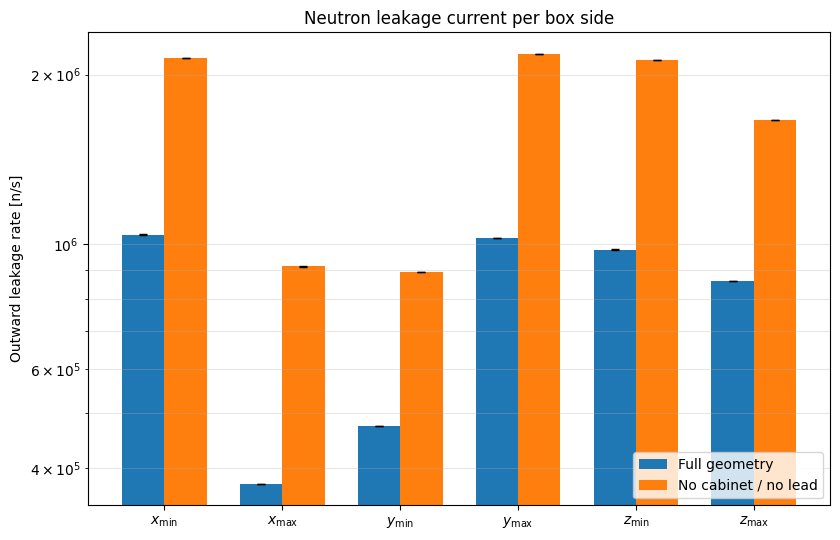

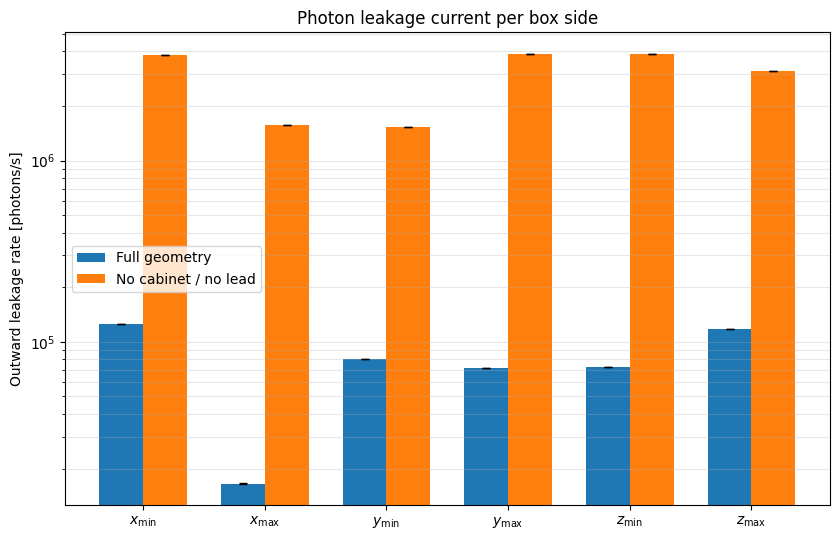

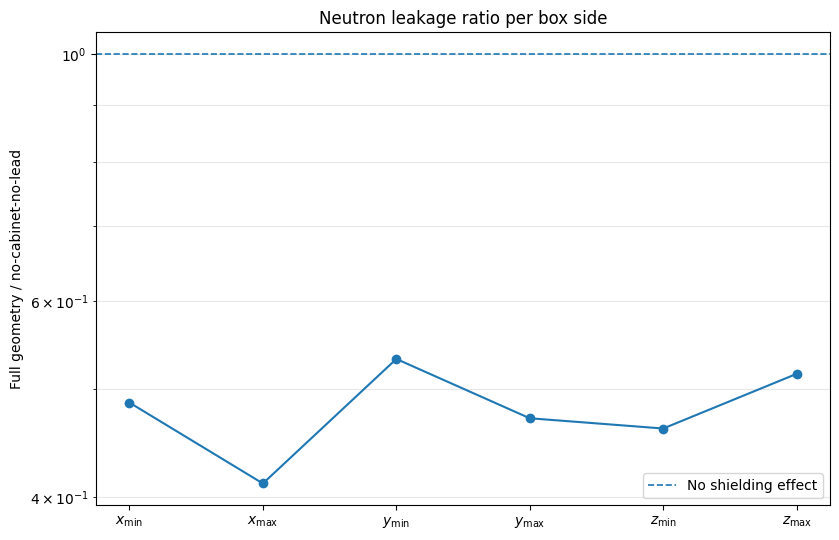

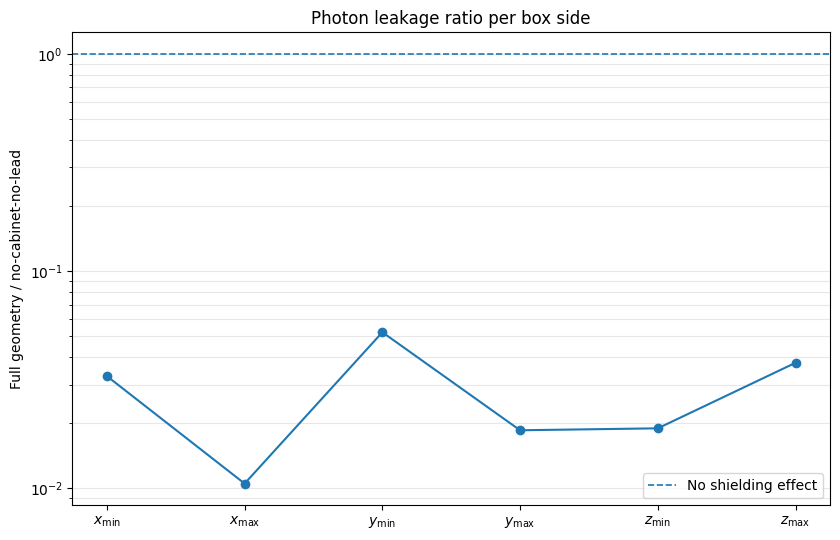

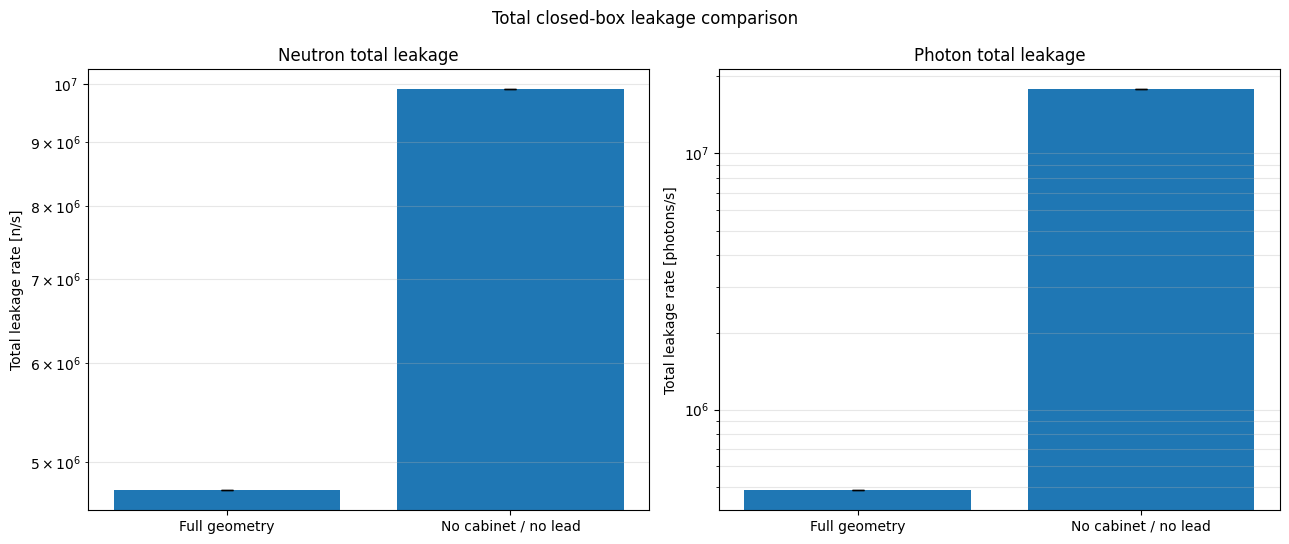

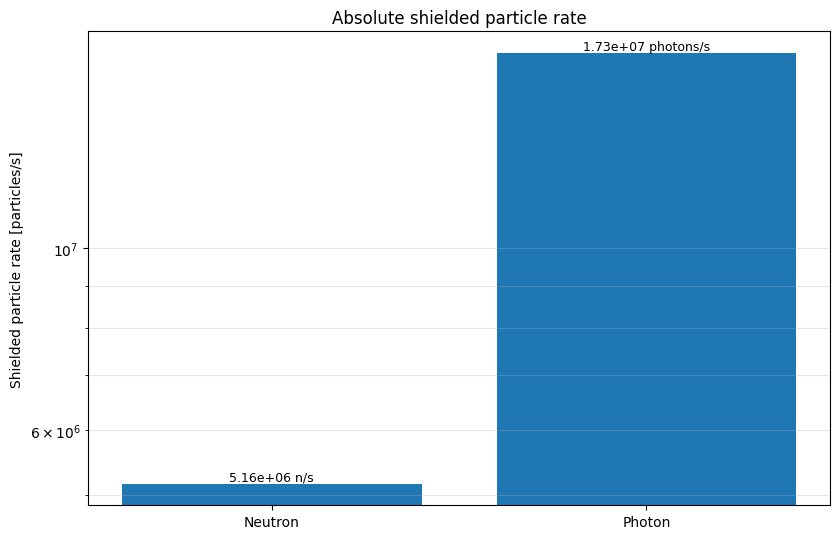

Leakage plot figures created:
  side_leakage_figures
  side_ratio_figures
  total_leakage_fig
  shielded_rate_fig

Main shielding effects:
  neutron : full/no-cabinet-no-lead = 0.4795, shielding effect = 52.05%
  photon  : full/no-cabinet-no-lead = 0.0273, shielding effect = 97.27%


In [112]:
# ============================================================
# 11) Plot leakage results
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Helper settings
# ------------------------------------------------------------

SIDE_ORDER = ["x_min", "x_max", "y_min", "y_max", "z_min", "z_max"]

SIDE_LABELS = {
    "x_min": r"$x_\mathrm{min}$",
    "x_max": r"$x_\mathrm{max}$",
    "y_min": r"$y_\mathrm{min}$",
    "y_max": r"$y_\mathrm{max}$",
    "z_min": r"$z_\mathrm{min}$",
    "z_max": r"$z_\mathrm{max}$",
}

SCENARIO_LABELS = {
    "full_geometry": "Full geometry",
    "no_cabinet_no_lead": "No cabinet / no lead",
}

PARTICLE_UNITS = {
    "neutron": "n/s",
    "photon": "photons/s",
}


def particle_title(particle):
    if particle == "neutron":
        return "Neutron"
    if particle == "photon":
        return "Photon"
    return str(particle).capitalize()


def leakage_rate_column_available(df):
    return (
        "outward_leakage_rate" in df.columns
        and np.isfinite(df["outward_leakage_rate"]).any()
    )


def get_particle_plot_columns(particle):
    """
    Use absolute rates for both particles when available.
    Otherwise fall back to normalized leakage per source particle.
    """
    particle_df = leakage_side_df[leakage_side_df["particle"] == particle]

    if leakage_rate_column_available(particle_df):
        return (
            "outward_leakage_rate",
            "outward_leakage_rate_std",
            PARTICLE_UNITS.get(particle, "1/s"),
        )

    return (
        "outward_leakage_per_source",
        "outward_leakage_std_per_source",
        "leakage per source particle",
    )


# ------------------------------------------------------------
# 11.1) Leakage current per side
# ------------------------------------------------------------

side_leakage_figures = {}

for particle in ["neutron", "photon"]:
    value_col, std_col, unit_label = get_particle_plot_columns(particle)

    fig, ax = plt.subplots(figsize=(8.5, 5.5))

    x = np.arange(len(SIDE_ORDER))
    width = 0.36

    for i, scenario in enumerate(["full_geometry", "no_cabinet_no_lead"]):
        sub = leakage_side_df[
            (leakage_side_df["particle"] == particle)
            & (leakage_side_df["scenario"] == scenario)
        ].copy()

        sub["side"] = pd.Categorical(sub["side"], categories=SIDE_ORDER, ordered=True)
        sub = sub.sort_values("side")

        offset = (i - 0.5) * width

        ax.bar(
            x + offset,
            sub[value_col],
            width=width,
            yerr=sub[std_col],
            capsize=3,
            label=SCENARIO_LABELS[scenario],
        )

    ax.set_yscale("log")
    ax.set_xticks(x)
    ax.set_xticklabels([SIDE_LABELS[s] for s in SIDE_ORDER])
    ax.set_ylabel(f"Outward leakage rate [{unit_label}]")
    ax.set_title(f"{particle_title(particle)} leakage current per box side")
    ax.grid(True, which="both", axis="y", alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()

    side_leakage_figures[f"{particle}_side_leakage_fig"] = fig


# ------------------------------------------------------------
# 11.2) Full vs no-cabinet/no-lead ratio per side
# ------------------------------------------------------------

side_ratio_figures = {}

for particle in ["neutron", "photon"]:
    sub = scenario_side_comparison_df[
        scenario_side_comparison_df["particle"] == particle
    ].copy()

    sub["side"] = pd.Categorical(sub["side"], categories=SIDE_ORDER, ordered=True)
    sub = sub.sort_values("side")

    fig, ax = plt.subplots(figsize=(8.5, 5.5))

    ax.errorbar(
        [SIDE_LABELS[s] for s in sub["side"]],
        sub["full_over_no_cabinet_no_lead_ratio"],
        yerr=sub["full_over_no_cabinet_no_lead_ratio_std"],
        marker="o",
        linestyle="-",
        capsize=3,
    )

    ax.axhline(1.0, linestyle="--", linewidth=1.2, label="No shielding effect")
    ax.set_yscale("log")
    ax.set_ylabel("Full geometry / no-cabinet-no-lead")
    ax.set_title(f"{particle_title(particle)} leakage ratio per box side")
    ax.grid(True, which="both", axis="y", alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()

    side_ratio_figures[f"{particle}_side_ratio_fig"] = fig


# ------------------------------------------------------------
# 11.3) Total leakage bar plot
# ------------------------------------------------------------

total_leakage_fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, particle in zip(axes, ["neutron", "photon"]):
    sub = total_leakage_df[total_leakage_df["particle"] == particle].copy()

    scenario_order = ["full_geometry", "no_cabinet_no_lead"]
    sub["scenario"] = pd.Categorical(sub["scenario"], categories=scenario_order, ordered=True)
    sub = sub.sort_values("scenario")

    labels = [SCENARIO_LABELS[s] for s in sub["scenario"]]

    if np.isfinite(sub["total_leakage_rate"]).any():
        values = sub["total_leakage_rate"]
        errors = sub["total_leakage_rate_std"]
        ylabel = f"Total leakage rate [{PARTICLE_UNITS.get(particle, '1/s')}]"
    else:
        values = sub["total_leakage_per_source"]
        errors = sub["total_leakage_std_per_source"]
        ylabel = "Total leakage per source particle"

    ax.bar(
        labels,
        values,
        yerr=errors,
        capsize=4,
    )

    ax.set_yscale("log")
    ax.set_title(f"{particle_title(particle)} total leakage")
    ax.set_ylabel(ylabel)
    ax.grid(True, which="both", axis="y", alpha=0.3)

total_leakage_fig.suptitle("Total closed-box leakage comparison")
total_leakage_fig.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11.4) Shielded rate comparison
# ------------------------------------------------------------

shielded_rate_fig, ax = plt.subplots(figsize=(8.5, 5.5))

plot_df = neutron_photon_shielding_df.copy()
plot_df = plot_df[np.isfinite(plot_df["shielded_rate"])].copy()

ax.bar(
    plot_df["particle"].map(particle_title),
    plot_df["shielded_rate"],
)

ax.set_yscale("log")
ax.set_ylabel("Shielded particle rate [particles/s]")
ax.set_title("Absolute shielded particle rate")
ax.grid(True, which="both", axis="y", alpha=0.3)

for i, row in enumerate(plot_df.itertuples()):
    ax.text(
        i,
        row.shielded_rate,
        f"{row.shielded_rate:.2e} {row.unit}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

shielded_rate_fig.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11.5) Compact print summary
# ------------------------------------------------------------

print("Leakage plot figures created:")
print("  side_leakage_figures")
print("  side_ratio_figures")
print("  total_leakage_fig")
print("  shielded_rate_fig")

print()
print("Main shielding effects:")
for row in scenario_effect_summary_df.itertuples():
    print(
        f"  {row.particle:8s}: full/no-cabinet-no-lead = "
        f"{row.full_over_no_cabinet_no_lead_ratio:.4f}, "
        f"shielding effect = {row.shielding_effect_percent:.2f}%"
    )

## 11A) Explanatory figure for box-surface labels
Shows clearly what x_min, x_max, y_min, y_max, z_min, and z_max mean

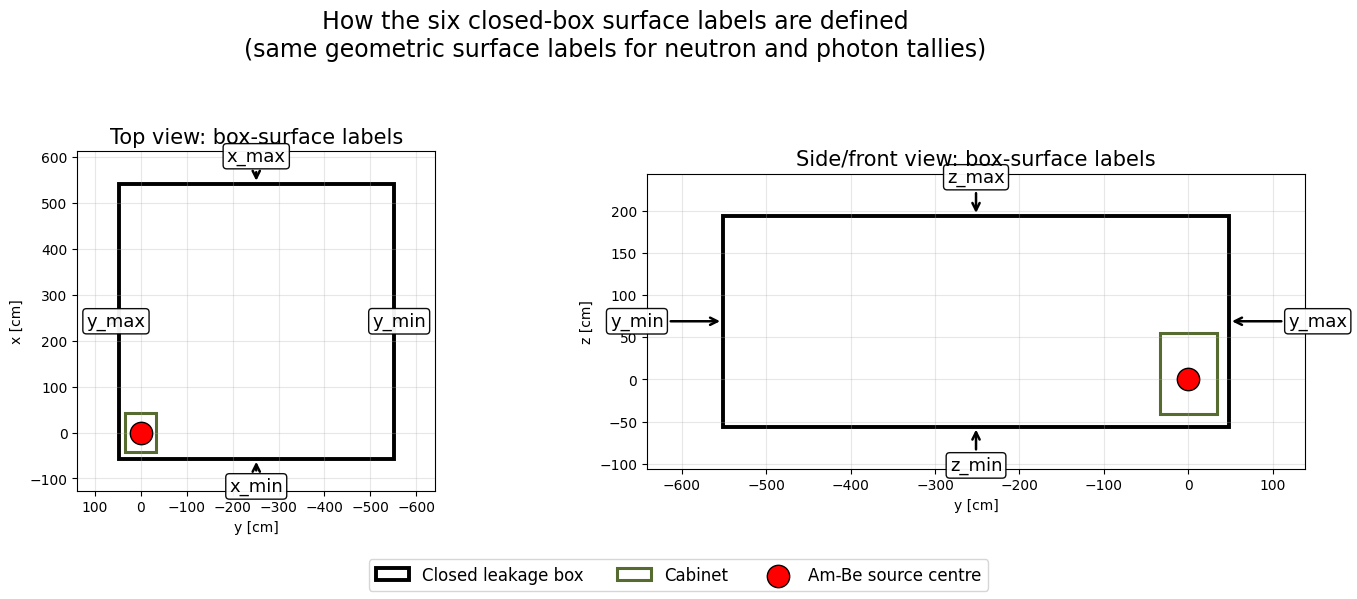

In [114]:
# ============================================================
# 11A) Clear explanatory figure for box-surface labels
#      Same surface naming for neutron and photon tallies
# ============================================================

from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

LABEL_BOX = dict(boxstyle="round,pad=0.2", fc="white", ec="black", alpha=0.95)

# ------------------------------------------------------------
# Left: top view
# horizontal = y
# vertical   = x
# ------------------------------------------------------------
ax = axes[0]

# Closed leakage box
ax.add_patch(
    Rectangle(
        (BOX_YMIN, BOX_XMIN),
        BOX_YMAX - BOX_YMIN,
        BOX_XMAX - BOX_XMIN,
        fill=False,
        edgecolor="black",
        linewidth=2.8,
        label="Closed leakage box",
    )
)

# Cabinet
ax.add_patch(
    Rectangle(
        (CABINET_YMIN, CABINET_XMIN),
        CABINET_YMAX - CABINET_YMIN,
        CABINET_XMAX - CABINET_XMIN,
        fill=False,
        edgecolor="darkolivegreen",
        linewidth=2.2,
        label="Cabinet",
    )
)

# Source
ax.scatter(
    [0.0], [0.0],
    s=260,
    color="red",
    edgecolor="black",
    zorder=5,
    label="Am-Be source centre"
)

xmid = 0.5 * (BOX_XMIN + BOX_XMAX)
ymid = 0.5 * (BOX_YMIN + BOX_YMAX)

# x_min
ax.annotate(
    "x_min",
    xy=(ymid, BOX_XMIN),
    xytext=(ymid, BOX_XMIN - 40),
    ha="center",
    va="top",
    fontsize=13,
    bbox=LABEL_BOX,
    arrowprops=dict(arrowstyle="->", lw=1.8),
    clip_on=False,
)

# x_max
ax.annotate(
    "x_max",
    xy=(ymid, BOX_XMAX),
    xytext=(ymid, BOX_XMAX + 40),
    ha="center",
    va="bottom",
    fontsize=13,
    bbox=LABEL_BOX,
    arrowprops=dict(arrowstyle="->", lw=1.8),
    clip_on=False,
)

# y_min
ax.annotate(
    "y_min",
    xy=(BOX_YMIN, xmid),
    xytext=(BOX_YMIN - 70, xmid),
    ha="right",
    va="center",
    fontsize=13,
    bbox=LABEL_BOX,
    arrowprops=dict(arrowstyle="->", lw=1.8),
    clip_on=False,
)

# y_max
ax.annotate(
    "y_max",
    xy=(BOX_YMAX, xmid),
    xytext=(BOX_YMAX + 70, xmid),
    ha="left",
    va="center",
    fontsize=13,
    bbox=LABEL_BOX,
    arrowprops=dict(arrowstyle="->", lw=1.8),
    clip_on=False,
)

ax.set_title("Top view: box-surface labels", fontsize=15)
ax.set_xlabel("y [cm]")
ax.set_ylabel("x [cm]")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.3)

pad_y = 90
pad_x = 70
ax.set_xlim(BOX_YMIN - pad_y, BOX_YMAX + pad_y)
ax.set_ylim(BOX_XMIN - pad_x, BOX_XMAX + pad_x)

if TOP_VIEW_MIRROR_Y:
    ax.invert_xaxis()


# ------------------------------------------------------------
# Right: side/front view
# horizontal = y
# vertical   = z
# ------------------------------------------------------------
ax = axes[1]

# Closed leakage box
ax.add_patch(
    Rectangle(
        (BOX_YMIN, BOX_ZMIN),
        BOX_YMAX - BOX_YMIN,
        BOX_ZMAX - BOX_ZMIN,
        fill=False,
        edgecolor="black",
        linewidth=2.8,
        label="Closed leakage box",
    )
)

# Cabinet
ax.add_patch(
    Rectangle(
        (CABINET_YMIN, CABINET_ZMIN),
        CABINET_YMAX - CABINET_YMIN,
        CABINET_ZMAX - CABINET_ZMIN,
        fill=False,
        edgecolor="darkolivegreen",
        linewidth=2.2,
        label="Cabinet",
    )
)

# Source
ax.scatter(
    [0.0], [0.0],
    s=260,
    color="red",
    edgecolor="black",
    zorder=5,
    label="Am-Be source centre"
)

zmid = 0.5 * (BOX_ZMIN + BOX_ZMAX)
ymid_side = 0.5 * (BOX_YMIN + BOX_YMAX)

# z_min
ax.annotate(
    "z_min",
    xy=(ymid_side, BOX_ZMIN),
    xytext=(ymid_side, BOX_ZMIN - 35),
    ha="center",
    va="top",
    fontsize=13,
    bbox=LABEL_BOX,
    arrowprops=dict(arrowstyle="->", lw=1.8),
    clip_on=False,
)

# z_max
ax.annotate(
    "z_max",
    xy=(ymid_side, BOX_ZMAX),
    xytext=(ymid_side, BOX_ZMAX + 35),
    ha="center",
    va="bottom",
    fontsize=13,
    bbox=LABEL_BOX,
    arrowprops=dict(arrowstyle="->", lw=1.8),
    clip_on=False,
)

# y_min
ax.annotate(
    "y_min",
    xy=(BOX_YMIN, zmid),
    xytext=(BOX_YMIN - 70, zmid),
    ha="right",
    va="center",
    fontsize=13,
    bbox=LABEL_BOX,
    arrowprops=dict(arrowstyle="->", lw=1.8),
    clip_on=False,
)

# y_max
ax.annotate(
    "y_max",
    xy=(BOX_YMAX, zmid),
    xytext=(BOX_YMAX + 70, zmid),
    ha="left",
    va="center",
    fontsize=13,
    bbox=LABEL_BOX,
    arrowprops=dict(arrowstyle="->", lw=1.8),
    clip_on=False,
)

ax.set_title("Side/front view: box-surface labels", fontsize=15)
ax.set_xlabel("y [cm]")
ax.set_ylabel("z [cm]")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.3)

ax.set_xlim(BOX_YMIN - pad_y, BOX_YMAX + pad_y)
ax.set_ylim(BOX_ZMIN - 50, BOX_ZMAX + 50)

if SIDE_VIEW_MIRROR_Y:
    ax.invert_xaxis()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=12)

fig.suptitle(
    "How the six closed-box surface labels are defined\n"
    "(same geometric surface labels for neutron and photon tallies)",
    fontsize=17
)

fig.tight_layout(rect=[0, 0.08, 1, 0.92])
plt.show()

surface_label_explanation_fig = fig

## 11B) Surface-current distribution map
Which box sides see the most / least leakage?

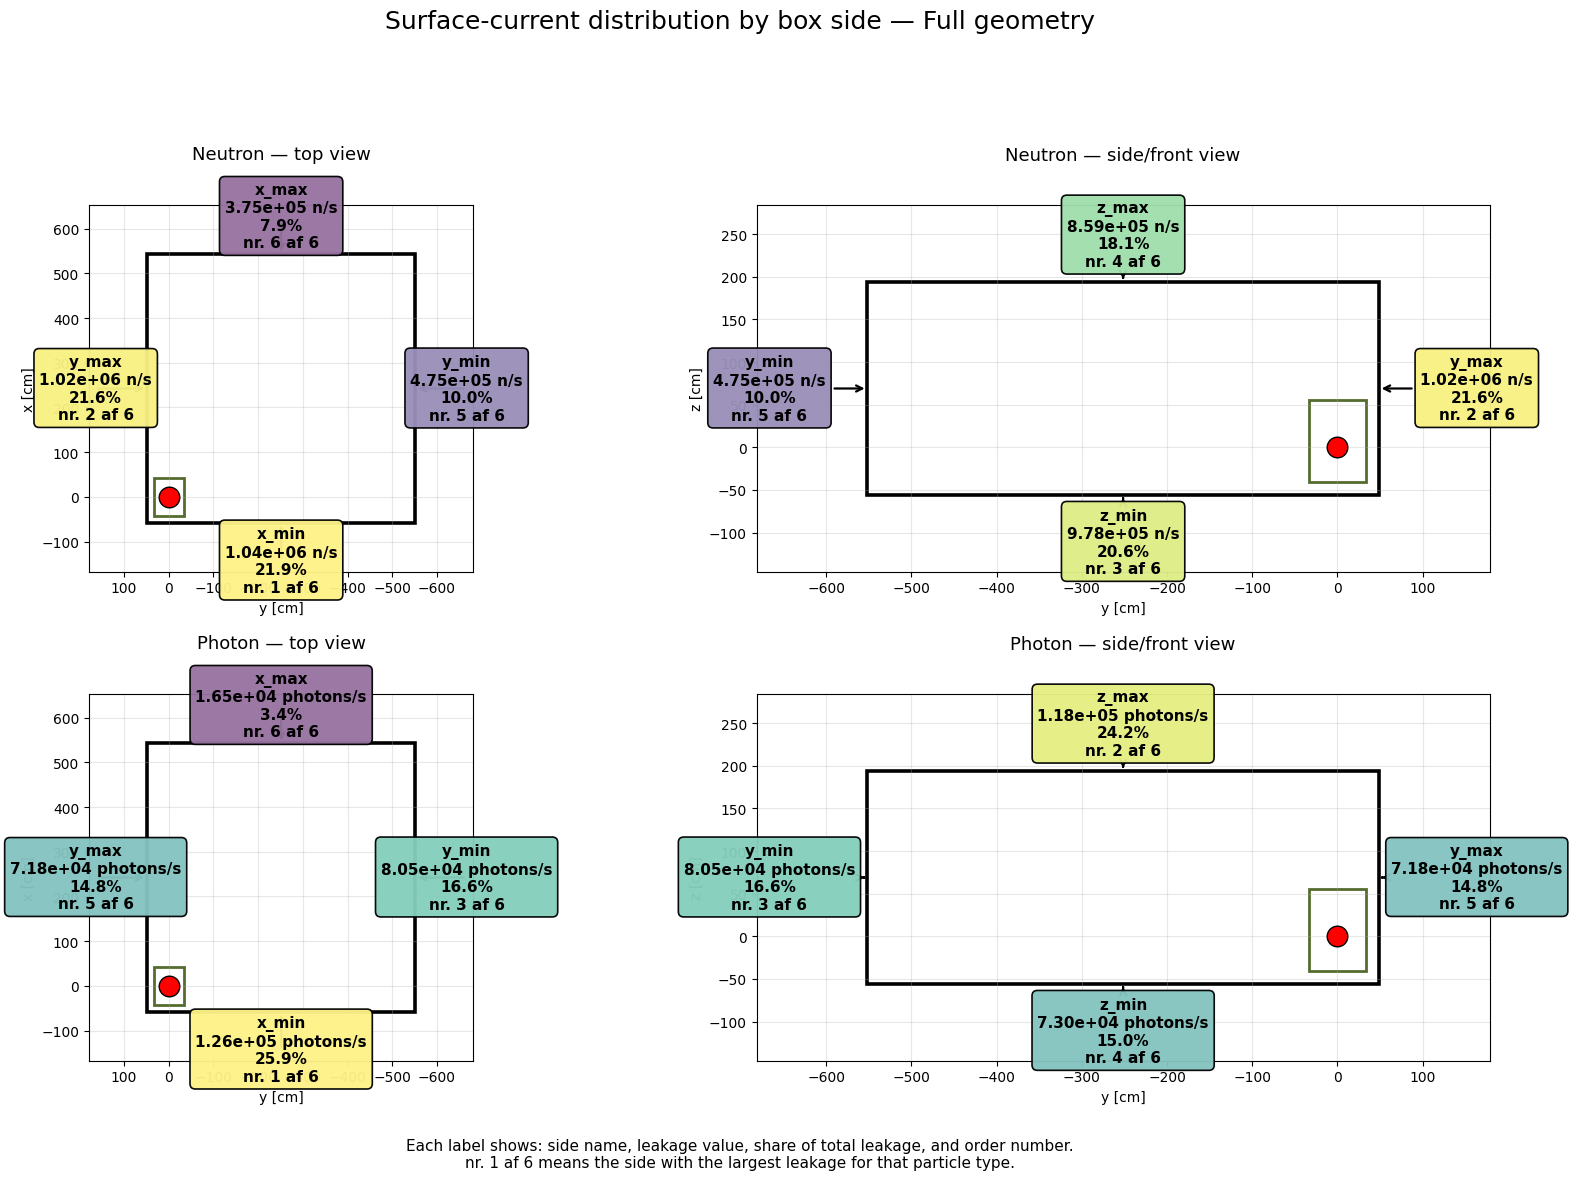

Surface order table, largest leakage to smallest leakage:


,particle,order_number_1_is_largest,side,leakage_value,unit,share_of_total_percent
0,neutron,1,x_min,1.039696e+06,n/s,21.883204
1,neutron,2,y_max,1.024746e+06,n/s,21.568524
2,neutron,3,z_min,9.779430e+05,n/s,20.583439
3,neutron,4,z_max,8.585922e+05,n/s,18.071381
4,neutron,5,y_min,4.749124e+05,n/s,9.995807
5,neutron,6,x_max,3.752262e+05,n/s,7.897644
6,photon,1,x_min,1.256025e+05,photons/s,25.903676
7,photon,2,z_max,1.175314e+05,photons/s,24.239133
8,photon,3,y_min,8.048337e+04,photons/s,16.598520
9,photon,4,z_min,7.296084e+04,photons/s,15.047106


In [ ]:
# ============================================================
# 11B) Surface-current distribution map
#      Which box sides see the most / least leakage?
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib import colors


# ------------------------------------------------------------
# Choose which scenario to visualize
# ------------------------------------------------------------

SCENARIO_TO_PLOT = "full_geometry"

SCENARIO_TITLE = {
    "full_geometry": "Full geometry",
    "no_cabinet_no_lead": "No cabinet / no lead",
}.get(SCENARIO_TO_PLOT, SCENARIO_TO_PLOT)

PARTICLES_TO_PLOT = ["neutron", "photon"]


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def choose_value_column(df_particle):
    """
    Use absolute rate if available, otherwise fall back to
    per-source normalized current.
    """

    if "outward_leakage_rate" in df_particle.columns:
        finite_mask = np.isfinite(df_particle["outward_leakage_rate"])

        if finite_mask.any():
            if "current_rate_unit" in df_particle.columns:
                unit_candidates = df_particle.loc[
                    df_particle["current_rate_unit"].notna(),
                    "current_rate_unit",
                ]

                unit = unit_candidates.iloc[0] if len(unit_candidates) > 0 else "particles/s"

            else:
                unit = "particles/s"

            return "outward_leakage_rate", unit

    return "outward_leakage_per_source", "per source"


def sci_fmt(x):
    return f"{x:.2e}"


def particle_title(particle):
    if particle == "neutron":
        return "Neutron"
    if particle == "photon":
        return "Photon"
    return str(particle).capitalize()


def get_particle_side_data(particle):
    dfp = leakage_side_df[
        (leakage_side_df["scenario"] == SCENARIO_TO_PLOT)
        & (leakage_side_df["particle"] == particle)
    ].copy()

    value_col, unit = choose_value_column(dfp)

    dfp["plot_value"] = dfp[value_col]
    dfp["order_number"] = dfp["plot_value"].rank(
        ascending=False,
        method="dense",
    ).astype(int)

    return dfp, value_col, unit


def add_box_and_cabinet_top(ax):
    ax.add_patch(
        Rectangle(
            (BOX_YMIN, BOX_XMIN),
            BOX_YMAX - BOX_YMIN,
            BOX_XMAX - BOX_XMIN,
            fill=False,
            edgecolor="black",
            linewidth=2.6,
        )
    )

    if SCENARIO_TO_PLOT == "full_geometry":
        ax.add_patch(
            Rectangle(
                (CABINET_YMIN, CABINET_XMIN),
                CABINET_YMAX - CABINET_YMIN,
                CABINET_XMAX - CABINET_XMIN,
                fill=False,
                edgecolor="darkolivegreen",
                linewidth=2.0,
            )
        )

    ax.scatter(
        [0.0],
        [0.0],
        s=220,
        color="red",
        edgecolor="black",
        zorder=5,
    )

    ax.set_xlabel("y [cm]")
    ax.set_ylabel("x [cm]")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)

    ax.set_xlim(BOX_YMIN - 130, BOX_YMAX + 130)
    ax.set_ylim(BOX_XMIN - 110, BOX_XMAX + 110)

    if TOP_VIEW_MIRROR_Y:
        ax.invert_xaxis()


def add_box_and_cabinet_side(ax):
    ax.add_patch(
        Rectangle(
            (BOX_YMIN, BOX_ZMIN),
            BOX_YMAX - BOX_YMIN,
            BOX_ZMAX - BOX_ZMIN,
            fill=False,
            edgecolor="black",
            linewidth=2.6,
        )
    )

    if SCENARIO_TO_PLOT == "full_geometry":
        ax.add_patch(
            Rectangle(
                (CABINET_YMIN, CABINET_ZMIN),
                CABINET_YMAX - CABINET_YMIN,
                CABINET_ZMAX - CABINET_ZMIN,
                fill=False,
                edgecolor="darkolivegreen",
                linewidth=2.0,
            )
        )

    ax.scatter(
        [0.0],
        [0.0],
        s=220,
        color="red",
        edgecolor="black",
        zorder=5,
    )

    ax.set_xlabel("y [cm]")
    ax.set_ylabel("z [cm]")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)

    ax.set_xlim(BOX_YMIN - 130, BOX_YMAX + 130)
    ax.set_ylim(BOX_ZMIN - 90, BOX_ZMAX + 90)

    if SIDE_VIEW_MIRROR_Y:
        ax.invert_xaxis()


def readable_label_color(color):
    """
    Make label boxes lighter, so black text remains readable.
    """
    rgba = np.array(color)
    white = np.array([1.0, 1.0, 1.0, 1.0])

    mixed = 0.55 * rgba + 0.45 * white
    mixed[3] = 0.96

    return mixed


def annotate_side(ax, xy, xytext, text, color):
    """
    Add a readable label box with an arrow pointing to a leakage-box side.
    """

    ax.annotate(
        text,
        xy=xy,
        xytext=xytext,
        textcoords="data",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor=readable_label_color(color),
            edgecolor="black",
            linewidth=1.2,
            alpha=0.96,
        ),
        arrowprops=dict(
            arrowstyle="->",
            color="black",
            lw=1.6,
        ),
        clip_on=False,
        zorder=10,
    )


def make_label_text(row, unit):
    return (
        f"{row['side']}\n"
        f"{sci_fmt(row['plot_value'])} {unit}\n"
        f"{100.0 * row['side_fraction_of_total_leakage']:.1f}%\n"
        f"nr. {row['order_number']} af 6"
    )


def draw_particle_distribution(ax_top, ax_side, dfp, particle, unit):
    add_box_and_cabinet_top(ax_top)
    add_box_and_cabinet_side(ax_side)

    # Titles moved upward to avoid overlap with label boxes
    ax_top.set_title(
        f"{particle_title(particle)} — top view",
        y=1.08,
        pad=12,
        fontsize=13,
    )

    ax_side.set_title(
        f"{particle_title(particle)} — side/front view",
        y=1.08,
        pad=12,
        fontsize=13,
    )

    values = dfp["plot_value"].values

    norm = colors.Normalize(
        vmin=np.nanmin(values),
        vmax=np.nanmax(values),
    )

    cmap = plt.cm.viridis

    side_lookup = {
        row["side"]: row
        for _, row in dfp.iterrows()
    }

    xmid = 0.5 * (BOX_XMIN + BOX_XMAX)
    ymid = 0.5 * (BOX_YMIN + BOX_YMAX)
    zmid = 0.5 * (BOX_ZMIN + BOX_ZMAX)

    # --------------------------------------------------------
    # Top view: x_min, x_max, y_min, y_max
    # --------------------------------------------------------

    top_positions = [
        ("x_min", (ymid, BOX_XMIN), (ymid, BOX_XMIN - 85)),
        ("x_max", (ymid, BOX_XMAX), (ymid, BOX_XMAX + 85)),
        ("y_min", (BOX_YMIN, xmid), (BOX_YMIN - 115, xmid)),
        ("y_max", (BOX_YMAX, xmid), (BOX_YMAX + 115, xmid)),
    ]

    for side, xy, xytext in top_positions:
        row = side_lookup[side]
        color = cmap(norm(row["plot_value"]))
        txt = make_label_text(row, unit)

        annotate_side(
            ax=ax_top,
            xy=xy,
            xytext=xytext,
            text=txt,
            color=color,
        )

    # --------------------------------------------------------
    # Side/front view: z_min, z_max, y_min, y_max
    # --------------------------------------------------------

    side_positions = [
        ("z_min", (ymid, BOX_ZMIN), (ymid, BOX_ZMIN - 55)),
        ("z_max", (ymid, BOX_ZMAX), (ymid, BOX_ZMAX + 55)),
        ("y_min", (BOX_YMIN, zmid), (BOX_YMIN - 115, zmid)),
        ("y_max", (BOX_YMAX, zmid), (BOX_YMAX + 115, zmid)),
    ]

    for side, xy, xytext in side_positions:
        row = side_lookup[side]
        color = cmap(norm(row["plot_value"]))
        txt = make_label_text(row, unit)

        annotate_side(
            ax=ax_side,
            xy=xy,
            xytext=xytext,
            text=txt,
            color=color,
        )

    return norm, cmap


# ------------------------------------------------------------
# Build figure
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(17, 12))

ranking_tables = []

for i, particle in enumerate(PARTICLES_TO_PLOT):
    dfp, value_col, unit = get_particle_side_data(particle)

    draw_particle_distribution(
        axes[i, 0],
        axes[i, 1],
        dfp,
        particle,
        unit,
    )

    ranking_tables.append(
        dfp[
            [
                "particle",
                "side",
                "plot_value",
                "side_fraction_of_total_leakage",
                "order_number",
            ]
        ]
        .sort_values("order_number")
        .assign(
            unit=unit,
            share_of_total_percent=lambda d: 100.0 * d["side_fraction_of_total_leakage"],
        )
    )


fig.suptitle(
    f"Surface-current distribution by box side — {SCENARIO_TITLE}",
    fontsize=18,
    y=0.995,
)

fig.text(
    0.5,
    0.03,
    "Each label shows: side name, leakage value, share of total leakage, and order number.\n"
    "nr. 1 af 6 means the side with the largest leakage for that particle type.",
    ha="center",
    fontsize=11,
)

# Slightly more top margin so subplot titles do not collide with labels
fig.tight_layout(rect=[0, 0.07, 1, 0.93])
plt.show()

surface_distribution_fig = fig


# ------------------------------------------------------------
# Ranking table
# ------------------------------------------------------------

surface_distribution_ranking_df = pd.concat(
    ranking_tables,
    ignore_index=True,
)

surface_distribution_ranking_df = surface_distribution_ranking_df.rename(
    columns={
        "plot_value": "leakage_value",
        "order_number": "order_number_1_is_largest",
    }
)

print("Surface order table, largest leakage to smallest leakage:")
display(
    surface_distribution_ranking_df[
        [
            "particle",
            "order_number_1_is_largest",
            "side",
            "leakage_value",
            "unit",
            "share_of_total_percent",
        ]
    ]
)

### Importent note:

The plots in this section are simplified geometry sketches used to visualize the closed leakage box and the surface labels. They are not full OpenMC renderings.

The actual OpenMC simulations use the full shared geometry from ambe_base_model.py for the `full_geometry` scenario.



### Surface-current distribution:

The surface-current distribution shows that the leakage is not isotropic. For the full geometry, the largest neutron leakage is through `x_min`, `y_max`, and `z_min`, while the smallest neutron leakage is through `x_max`. This reflects the asymmetric placement of the source, cabinet, paraffin moderator, and lead shielding inside the closed box.

For photons, the shielding effect is much stronger. The photon leakage is dominated by `x_min` and `z_max`, while `x_max` is strongly suppressed. This is consistent with the lead shielding reducing the photon current much more effectively than the neutron current.

The labels `x_min`, `x_max`, `y_min`, `y_max`, `z_min`, and `z_max` are the six physical faces of the leakage box. The same face labels are used for both neutron and photon tallies.

# 12) Save final leakage outputs

This section saves the final results from the closed-box surface-current leakage calculation.

The saved outputs include:

- surface-current result tables,
- total leakage tables,
- scenario comparison tables,
- figures,
- metadata describing the closed leakage box and source scaling.

These files are saved in the folder `surface_current_leakage_outputs`.

In [121]:
# ============================================================
# 12) Save final leakage outputs
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

LEAKAGE_OUTPUT_DIR = Path("surface_current_leakage_outputs")
LEAKAGE_TABLE_DIR = LEAKAGE_OUTPUT_DIR / "tables"
LEAKAGE_FIGURE_DIR = LEAKAGE_OUTPUT_DIR / "figures"
LEAKAGE_METADATA_DIR = LEAKAGE_OUTPUT_DIR / "metadata"

LEAKAGE_TABLE_DIR.mkdir(parents=True, exist_ok=True)
LEAKAGE_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
LEAKAGE_METADATA_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 12.1) Save result tables
# ------------------------------------------------------------

table_outputs = {
    "surface_current_results.csv": surface_current_results_df,
    "leakage_side_results.csv": leakage_side_df,
    "total_leakage_results.csv": total_leakage_df,
    "scenario_total_comparison.csv": scenario_total_comparison_df,
    "scenario_side_comparison.csv": scenario_side_comparison_df,
    "scenario_effect_summary.csv": scenario_effect_summary_df,
    "neutron_photon_shielding_summary.csv": neutron_photon_shielding_df,
}

if "source_scaling_df" in globals():
    table_outputs["source_scaling_summary.csv"] = source_scaling_df

if "surface_distribution_ranking_df" in globals():
    table_outputs["surface_distribution_ranking.csv"] = surface_distribution_ranking_df

saved_table_paths = []

for filename, df in table_outputs.items():
    path = LEAKAGE_TABLE_DIR / filename
    df.to_csv(path, index=False)
    saved_table_paths.append(path)


# Also save the most important summary table directly in the main project folder
final_summary_path = Path("closed_box_surface_current_leakage_summary.csv")
scenario_effect_summary_df.to_csv(final_summary_path, index=False)


# ------------------------------------------------------------
# 12.2) Save figures
# ------------------------------------------------------------

saved_figure_paths = []

figure_outputs = {}

if "leakage_scenario_geometry_zoom_fig" in globals():
    figure_outputs["closed_box_geometry_overview.png"] = leakage_scenario_geometry_zoom_fig

if "surface_label_explanation_fig" in globals():
    figure_outputs["closed_box_surface_label_explanation.png"] = surface_label_explanation_fig

if "surface_distribution_fig" in globals():
    figure_outputs["closed_box_surface_current_distribution.png"] = surface_distribution_fig

if "total_leakage_fig" in globals():
    figure_outputs["total_leakage_comparison.png"] = total_leakage_fig

if "shielded_rate_fig" in globals():
    figure_outputs["absolute_shielded_particle_rate.png"] = shielded_rate_fig

if "side_leakage_figures" in globals():
    for name, fig in side_leakage_figures.items():
        figure_outputs[f"{name}.png"] = fig

if "side_ratio_figures" in globals():
    for name, fig in side_ratio_figures.items():
        figure_outputs[f"{name}.png"] = fig


for filename, fig in figure_outputs.items():
    path = LEAKAGE_FIGURE_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    saved_figure_paths.append(path)


# ------------------------------------------------------------
# 12.3) Save metadata
# ------------------------------------------------------------

box_metadata = {
    "BOX_CLEARANCE_CM": BOX_CLEARANCE_CM,
    "BOX_SIZE_X_CM": BOX_SIZE_X_CM,
    "BOX_SIZE_Y_CM": BOX_SIZE_Y_CM,
    "BOX_SIZE_Z_CM": BOX_SIZE_Z_CM,

    "BOX_XMIN": BOX_XMIN,
    "BOX_XMAX": BOX_XMAX,
    "BOX_YMIN": BOX_YMIN,
    "BOX_YMAX": BOX_YMAX,
    "BOX_ZMIN": BOX_ZMIN,
    "BOX_ZMAX": BOX_ZMAX,

    "CABINET_XMIN": CABINET_XMIN,
    "CABINET_XMAX": CABINET_XMAX,
    "CABINET_YMIN": CABINET_YMIN,
    "CABINET_YMAX": CABINET_YMAX,
    "CABINET_ZMIN": CABINET_ZMIN,
    "CABINET_ZMAX": CABINET_ZMAX,
}

source_metadata = {
    "SOURCE_NEUTRON_EMISSION_n_per_s": SOURCE_NEUTRON_EMISSION
    if "SOURCE_NEUTRON_EMISSION" in globals()
    else getattr(ambe_base_model, "SOURCE_NEUTRON_EMISSION", np.nan),

    "SOURCE_GAMMA_EMISSION_photons_per_s": SOURCE_GAMMA_EMISSION
    if "SOURCE_GAMMA_EMISSION" in globals()
    else getattr(ambe_base_model, "SOURCE_GAMMA_EMISSION", np.nan),

    "GAMMA_PER_NEUTRON_RATIO": GAMMA_PER_NEUTRON_RATIO
    if "GAMMA_PER_NEUTRON_RATIO" in globals()
    else np.nan,
}

run_metadata = {
    "SURFACE_CURRENT_BATCHES": SURFACE_CURRENT_BATCHES,
    "SURFACE_CURRENT_PARTICLES": SURFACE_CURRENT_PARTICLES,
    "SURFACE_CURRENT_INACTIVE": SURFACE_CURRENT_INACTIVE,
    "number_of_models": len(surface_current_models),
}

metadata_df = pd.DataFrame(
    [
        {"category": "box", "name": key, "value": value}
        for key, value in box_metadata.items()
    ]
    +
    [
        {"category": "source", "name": key, "value": value}
        for key, value in source_metadata.items()
    ]
    +
    [
        {"category": "run", "name": key, "value": value}
        for key, value in run_metadata.items()
    ]
)

metadata_path = LEAKAGE_METADATA_DIR / "closed_box_leakage_metadata.csv"
metadata_df.to_csv(metadata_path, index=False)


# ------------------------------------------------------------
# 12.4) Save statepoint index
# ------------------------------------------------------------

statepoint_index_df = pd.DataFrame(
    [
        {
            "model_key": model_key,
            "statepoint_path": str(path),
        }
        for model_key, path in surface_current_statepoints.items()
    ]
)

statepoint_index_path = LEAKAGE_METADATA_DIR / "statepoint_index.csv"
statepoint_index_df.to_csv(statepoint_index_path, index=False)


# ------------------------------------------------------------
# 12.5) Print summary
# ------------------------------------------------------------

print("Saved leakage-output tables:")
for path in saved_table_paths:
    print(f"  {path.resolve()}")

print()
print("Saved main summary table:")
print(f"  {final_summary_path.resolve()}")

print()
print("Saved figures:")
if saved_figure_paths:
    for path in saved_figure_paths:
        print(f"  {path.resolve()}")
else:
    print("  No figure objects found to save.")

print()
print("Saved metadata:")
print(f"  {metadata_path.resolve()}")
print(f"  {statepoint_index_path.resolve()}")

print()
print("Output folders:")
print(f"  Tables:   {LEAKAGE_TABLE_DIR.resolve()}")
print(f"  Figures:  {LEAKAGE_FIGURE_DIR.resolve()}")
print(f"  Metadata: {LEAKAGE_METADATA_DIR.resolve()}")

Saved leakage-output tables:
  /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/surface_current_leakage_outputs/tables/surface_current_results.csv
  /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/surface_current_leakage_outputs/tables/leakage_side_results.csv
  /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/surface_current_leakage_outputs/tables/total_leakage_results.csv
  /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/surface_current_leakage_outputs/tables/scenario_total_comparison.csv
  /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/surface_current_leakage_outputs/tables/scenario_side_comparison.csv
  /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/surface_current_leakage_outputs/tables/scenario_effect_summary.csv
  /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/surface_current_leakage_outputs/tables/neutron_photon_shielding_summary.csv
  /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/surface

# 13) Summary and conclusion

This notebook used an OpenMC closed-box surface-current tally to estimate the total particle leakage from the Am-Be source setup. The tally box was placed around the experimental geometry with approximately $15\ \mathrm{cm}$ clearance between the cabinet and the nearest box surfaces.

Two geometry scenarios were compared:

1. the full geometry, including the cabinet walls and lead shielding,
2. the same source and moderator setup without cabinet walls and without lead shielding.

For each scenario, separate neutron and photon simulations were performed.

## What the current tally measures

The surface-current tally measures the net particle current crossing each of the six surfaces of the closed box:

$$
x_\mathrm{min},\ x_\mathrm{max},\ y_\mathrm{min},\ y_\mathrm{max},\ z_\mathrm{min},\ z_\mathrm{max}.
$$

These labels denote the six physical faces of the leakage box. They are not minimum or maximum measured flux values; they are the boundary surfaces through which particles leave the box. The same surface labels are used for both neutron and photon tallies.

The tally therefore estimates how many particles escape through each side of the box. Summing the outward current over all six surfaces gives the total leakage from the closed box.

## Main neutron and photon leakage directions

The leakage is not distributed isotropically over the six box surfaces. This is expected, because the source, paraffin moderator, cabinet, lead shielding and box placement are all geometrically asymmetric.

For the full geometry, the neutron leakage is largest through the sides closest to the source and the least shielded directions. In the final surface-current distribution, the largest neutron leakage occurs through `x_min`, followed by `y_max` and `z_min`. The smallest neutron leakage occurs through `x_max`.

For photons, the distribution is more strongly affected by the lead shielding and cabinet geometry. The largest photon leakage occurs through `x_min`, while the smallest photon leakage occurs through `x_max`. Compared with the neutron case, the photon leakage is much more strongly suppressed by the full geometry.

## Effect of cabinet and lead shielding

The comparison between the full geometry and the no-cabinet/no-lead case gives an estimate of the shielding effect from the cabinet and lead bricks.

For neutrons, the full geometry leakage is approximately $0.479$ times the no-cabinet/no-lead leakage. This corresponds to a reduction of about $52.1%$.

For photons, the full geometry leakage is approximately $0.027$ times the no-cabinet/no-lead leakage. This corresponds to a reduction of about $97.3%$.

Thus, the model predicts that the cabinet and lead shielding reduce the photon leakage much more strongly than the neutron leakage. This is physically reasonable, since lead is very effective for attenuating photons, while neutrons are less effectively shielded by lead alone and require moderation and absorption processes.

Using the ALPHANSO-based source scaling, the estimated absolute shielded rates are approximately

$$
5.16 \times 10^6\ \mathrm{n/s}
$$

for neutrons and

$$
1.73 \times 10^7\ \mathrm{photons/s}
$$

for photons. The absolute shielded photon rate is therefore about $3.36$ times larger than the absolute shielded neutron rate.

## Relation to later point-dose and measurement notebooks

This notebook does not calculate the local dose rate at individual detector positions. Instead, it gives a global leakage estimate from the entire setup by integrating the escaping particle current over a closed surface.

The result is therefore complementary to the later point-dose and measurement notebooks:

* the surface-current tally gives the total leakage from the setup,
* the point-dose simulations estimate the radiation field at specific detector positions,
* the measured neutron and gamma notebooks analyse the experimental detector readings,
* the final comparison notebook can compare the simulated and measured spatial radiation fields.

The closed-box leakage calculation is therefore useful as a global consistency check. It shows how much radiation escapes the complete setup, which sides of the surrounding box receive the largest particle current, and how strongly the cabinet and lead shielding affect neutron and photon leakage.


In [122]:
# ============================================================
# 13) Print compact numerical conclusion
# ============================================================

print("Closed-box surface-current leakage summary")
print("=" * 60)

for row in scenario_effect_summary_df.itertuples():
    print(
        f"{row.particle.capitalize():8s}: "
        f"full/no-cabinet-no-lead = "
        f"{row.full_over_no_cabinet_no_lead_ratio:.4f}, "
        f"shielding effect = {row.shielding_effect_percent:.2f}%"
    )

print()
print("Absolute shielded particle rates:")
for row in neutron_photon_shielding_df.itertuples():
    print(
        f"{row.particle.capitalize():8s}: "
        f"{row.shielded_rate:.6e} {row.unit}, "
        f"shielded fraction = {row.shielded_fraction:.4f}"
    )

if "photon_to_neutron_shielded_ratio" in globals():
    print()
    print(
        "Shielded photon/neutron rate ratio: "
        f"{photon_to_neutron_shielded_ratio:.4f}"
    )

Closed-box surface-current leakage summary
Neutron : full/no-cabinet-no-lead = 0.4795, shielding effect = 52.05%
Photon  : full/no-cabinet-no-lead = 0.0273, shielding effect = 97.27%

Absolute shielded particle rates:
Neutron : 5.158079e+06 n/s, shielded fraction = 0.5205
Photon  : 1.730605e+07 photons/s, shielded fraction = 0.9727

Shielded photon/neutron rate ratio: 3.3551


The ALPHANSO-based source scaling gives an estimated production ratio of
$$
S_n     = 1.20 × 10^7 n/s
$$

$$
{S_\gamma} = 7.83 × 10^6 photons/s
$$


$$
\frac{S_\gamma}{S_n} \approx 0.652\ \mathrm{photons/neutron}.
$$

Thus, the source produces fewer photons than neutrons in the adopted source model. However, the shielding calculation shows that the absolute shielded photon rate is larger than the shielded neutron rate:

$$
\frac{\mathrm{shielded\ photons/s}}{\mathrm{shielded\ neutrons/s}}
\approx 3.36.
$$

This occurs because the full geometry reduces photon leakage much more strongly than neutron leakage. The estimated reduction is approximately $97.3\%$ for photons, compared with approximately $52.1\%$ for neutrons.

## Literature comparison for the Am-Be gamma-to-neutron ratio

The photon source strength used in this notebook was estimated from the ALPHANSO gamma yield relative to the ALPHANSO neutron yield. The resulting model-specific photon-to-neutron source ratio was

$$
\frac{S_\gamma}{S_n} = 0.652.
$$

With the assumed neutron emission rate

$$
S_n = 1.2 \times 10^7\ \mathrm{n/s},
$$

this gives

$$
S_\gamma = 7.83 \times 10^6\ \mathrm{photons/s}.
$$

This value should be interpreted as an ALPHANSO-based model estimate. It is useful to compare it with literature values for the 4.438 MeV gamma line from Am-Be sources.

Most published values refer specifically to the 4.438 MeV gamma ray from the de-excitation of the first excited state of ${}^{12}\mathrm{C}$,

$$
{}^{9}\mathrm{Be}(\alpha,n){}^{12}\mathrm{C}^{\ast},
$$

followed by

$$
{}^{12}\mathrm{C}^{\ast} \rightarrow {}^{12}\mathrm{C}+\gamma(4.438\ \mathrm{MeV}).
$$

Therefore, the literature values usually describe the ratio of 4.438 MeV gamma rays to total emitted neutrons, not necessarily all photons emitted by the source.

A commonly cited evaluated value is

$$
R = \frac{S_\gamma}{S_n} = 0.575 \pm 0.028,
$$

or equivalently about $0.575$ 4.438 MeV gamma rays per emitted neutron. This value is reported and used in several Am-Be source studies.

| Source / method                                      |            Reported ratio | Estimated photon emission for $S_n = 1.2\times10^7\ \mathrm{n/s}$ |
| ---------------------------------------------------- | ------------------------: | ----------------------------------------------------------------: |
| Liu et al., evaluated 4.438 MeV gamma/neutron ratio  |     $R = 0.575 \pm 0.028$ |                               $6.90\times10^6\ \gamma/\mathrm{s}$ |
| Mowlavi / Koohi-Fayegh and tagged-neutron literature | approximately $0.55-0.60$ |                          $(6.6-7.2)\times10^6\ \gamma/\mathrm{s}$ |
| ALPHANSO value used in this notebook                 |               $R = 0.652$ |                               $7.83\times10^6\ \gamma/\mathrm{s}$ |

The ALPHANSO-based value used here is therefore somewhat higher than the frequently cited value $R=0.575$. The relative difference is

$$
\frac{0.652-0.575}{0.575} \approx 0.134,
$$

or about $13.4%$.

Thus, the photon leakage rates in this notebook should be interpreted as model-dependent absolute estimates. The shielding ratios are more robust, because the ratios between the full-geometry and no-cabinet/no-lead photon simulations are normalized in the same way.

For reference, the main external sources used for comparison are:

* [Liu et al., *The 4.438 MeV gamma to neutron ratio for the Am-Be neutron source*, Applied Radiation and Isotopes, 2007](https://pubmed.ncbi.nlm.nih.gov/17574426/)
* [Mowlavi and Koohi-Fayegh, *Determination of 4.438 MeV gamma-ray to neutron emission ratio from a ${}^{241}$Am-${}^{9}$Be neutron source*, Applied Radiation and Isotopes, 2004](https://pubmed.ncbi.nlm.nih.gov/15110363/)
* [Csedreki et al., *Characterization of the LUNA neutron detector array*, arXiv/PDF, uses $R=0.575\pm0.028$](https://arxiv.org/pdf/2411.05053)
* [ResearchGate entry for Liu et al. with the evaluated $R=0.575\pm0.028$ value](https://www.researchgate.net/publication/222256642_The_4438MeV_gamma_to_neutron_ratio_for_the_Am-Be_neutron_source)
